# Run Analysis (PC_1 vs PC_2, kept separate)

This notebook performs run analysis using only the two configured run IDs, with strict separation between machines:
- PC_1: `38658B597A958827`
- PC_2: `043314E3154FFE42`

What it does:
1. Loads `query_timing` (RAPL) and `sigless` (external power) logs.
2. Chunks sigless traces using `start/end` MESSAGE markers for each run.
3. Computes per-run metrics for external and RAPL data.
4. Performs A/B comparisons by query family for each PC separately.
5. Produces A/B plots for Average Power, Total Energy, and Runtime.
6. Runs per-family A/B hypothesis tests and reports which test was used.
7. Runs a cross-PC rank test to check whether family rankings agree between PCs.

In [1]:
import csv
import json
import re
from pathlib import Path

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import shapiro, ttest_ind, mannwhitneyu, spearmanr

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 120

In [2]:
PCS = {
    "PC_1": {
        "run_id": "38658B597A958827",
        "query_timing_file": Path("logs/query_timing_1.csv"),
        "sigless_file": Path("logs/sigless.1774008714209.CH1-0.csv"),
    },
    "PC_2": {
        "run_id": "043314E3154FFE42",
        "query_timing_file": Path("logs/query_timing.csv"),
        "sigless_file": Path("logs/sigless.1774008746572.CH1-0.csv"),
    },
}

for pc_name, cfg in PCS.items():
    print(pc_name, cfg["run_id"])
    print("  query_timing:", cfg["query_timing_file"].resolve())
    print("  sigless:", cfg["sigless_file"].resolve())

PC_1 38658B597A958827
  query_timing: C:\Users\matth\Desktop\Masters-Thesis\logs\query_timing_1.csv
  sigless: C:\Users\matth\Desktop\Masters-Thesis\logs\sigless.1774008714209.CH1-0.csv
PC_2 043314E3154FFE42
  query_timing: C:\Users\matth\Desktop\Masters-Thesis\logs\query_timing.csv
  sigless: C:\Users\matth\Desktop\Masters-Thesis\logs\sigless.1774008746572.CH1-0.csv


In [3]:
import csv
import json
import re
from pathlib import Path

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import shapiro, ttest_ind, mannwhitneyu, spearmanr

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 120


def parse_message_payload(payload: str) -> dict:
    payload_obj = json.loads(payload)
    message_text = payload_obj.get("message", "")

    fields = {
        "action": None,
        "channelId": payload_obj.get("channelId"),
        "message_timestamp": payload_obj.get("timestamp"),
    }

    parts = [p.strip() for p in message_text.split(",") if p.strip()]
    if parts:
        fields["action"] = parts[0].lower()

    for token in parts[1:]:
        if "=" in token:
            k, v = token.split("=", 1)
            fields[k.strip()] = v.strip()

    return fields


def parse_loop_index(loop_value):
    if loop_value is None or (isinstance(loop_value, float) and np.isnan(loop_value)):
        return np.nan
    text = str(loop_value).strip()
    if "/" in text:
        text = text.split("/", 1)[0]
    try:
        return int(text)
    except ValueError:
        return np.nan


def parse_test_name(test_name: str):
    m = re.match(r"^(?P<family>.+)-query(?P<variant>[AB])\.sql$", str(test_name))
    if not m:
        return None, None
    return m.group("family"), f"QUERY{m.group('variant').upper()}"


def build_external_metrics(sigless_file: Path, run_id_filter: str) -> pd.DataFrame:
    records = []
    active_run = None
    active_power_rows = []

    with sigless_file.open("r", newline="", encoding="utf-8") as handle:
        reader = csv.reader(handle)
        header = next(reader, None)

        for row in reader:
            if len(row) < 4:
                continue

            ts_raw, channel, action, payload = row[0], row[1], row[2].strip(), row[3]
            try:
                timestamp = int(ts_raw)
            except ValueError:
                continue

            if action == "MESSAGE":
                msg = parse_message_payload(payload)
                msg_action = msg.get("action")

                if msg_action == "start":
                    if str(msg.get("run_id", "")) != run_id_filter:
                        continue

                    if active_run is not None:
                        active_run["status"] = "incomplete_missing_end"
                        records.append(active_run)

                    active_run = {
                        "run_id": str(msg.get("run_id")),
                        "test_name": msg.get("test"),
                        "loop_raw": msg.get("loop"),
                        "loop_index": parse_loop_index(msg.get("loop")),
                        "runs": pd.to_numeric(msg.get("runs"), errors="coerce"),
                        "start_ts": timestamp,
                        "status": "open",
                    }
                    active_power_rows = []

                elif msg_action == "end" and active_run is not None:
                    active_run["end_ts"] = timestamp
                    active_run["elapsed_sec_message"] = pd.to_numeric(msg.get("elapsed_sec"), errors="coerce")
                    active_run["failures_message"] = pd.to_numeric(msg.get("failures"), errors="coerce")

                    power_df = pd.DataFrame(active_power_rows)
                    if not power_df.empty:
                        power_df = power_df.sort_values("timestamp").reset_index(drop=True)
                        power_df["time_s"] = (power_df["timestamp"] - power_df["timestamp"].min()) / 1000.0
                        measured_window_sec = float(power_df["time_s"].iloc[-1]) if len(power_df) > 1 else 0.0
                        energy_j = float(np.trapz(power_df["power_w"].to_numpy(), power_df["time_s"].to_numpy())) if len(power_df) > 1 else 0.0
                        avg_power_w = energy_j / measured_window_sec if measured_window_sec > 0 else np.nan

                        active_run["external_samples"] = int(power_df.shape[0])
                        active_run["external_window_sec"] = measured_window_sec
                        active_run["external_energy_j"] = energy_j
                        active_run["external_avg_power_w"] = avg_power_w
                        active_run["external_peak_power_w"] = float(power_df["power_w"].max())
                        active_run["external_min_power_w"] = float(power_df["power_w"].min())
                        active_run["external_std_power_w"] = float(power_df["power_w"].std(ddof=1)) if power_df.shape[0] > 1 else 0.0
                        active_run["status"] = "complete"
                    else:
                        active_run["external_samples"] = 0
                        active_run["external_window_sec"] = np.nan
                        active_run["external_energy_j"] = np.nan
                        active_run["external_avg_power_w"] = np.nan
                        active_run["external_peak_power_w"] = np.nan
                        active_run["external_min_power_w"] = np.nan
                        active_run["external_std_power_w"] = np.nan
                        active_run["status"] = "complete_no_power_rows"

                    records.append(active_run)
                    active_run = None
                    active_power_rows = []

            elif action.startswith("POWER") and active_run is not None:
                try:
                    power_val = float(payload)
                except ValueError:
                    continue

                active_power_rows.append({"timestamp": timestamp, "power_w": power_val})

    if active_run is not None:
        active_run["status"] = "incomplete_missing_end"
        active_run["external_samples"] = len(active_power_rows)
        records.append(active_run)

    ext_df = pd.DataFrame(records)
    if ext_df.empty:
        return ext_df

    ext_df["message_duration_sec"] = (ext_df.get("end_ts", np.nan) - ext_df["start_ts"]) / 1000.0
    return ext_df


def build_rapl_metrics(query_timing_file: Path, run_id_filter: str) -> pd.DataFrame:
    qdf = pd.read_csv(query_timing_file)
    qdf = qdf[qdf["run_id"].astype(str) == str(run_id_filter)].copy()

    numeric_cols = ["loop_index", "total_elapsed_sec", "rapl_package_j", "rapl_core_j", "failures", "runs_per_loop", "total_runs"]
    for col in numeric_cols:
        if col in qdf.columns:
            qdf[col] = pd.to_numeric(qdf[col], errors="coerce")

    qdf["rapl_avg_power_w"] = qdf["rapl_package_j"] / qdf["total_elapsed_sec"]
    qdf["loop_index"] = qdf["loop_index"].astype("Int64")

    keep_cols = [
        "run_id",
        "test_name",
        "loop_index",
        "total_elapsed_sec",
        "rapl_package_j",
        "rapl_core_j",
        "rapl_avg_power_w",
        "failures",
        "runs_per_loop",
        "total_runs",
    ]
    keep_cols = [c for c in keep_cols if c in qdf.columns]
    return qdf[keep_cols].copy()

In [4]:
# Override with a robust reader for malformed lines in query_timing CSVs.
def build_rapl_metrics(query_timing_file: Path, run_id_filter: str) -> pd.DataFrame:
    qdf = pd.read_csv(query_timing_file, engine="python", on_bad_lines="skip")
    qdf = qdf[qdf["run_id"].astype(str) == str(run_id_filter)].copy()

    numeric_cols = ["loop_index", "total_elapsed_sec", "rapl_package_j", "rapl_core_j", "failures", "runs_per_loop", "total_runs"]
    for col in numeric_cols:
        if col in qdf.columns:
            qdf[col] = pd.to_numeric(qdf[col], errors="coerce")

    # Remove malformed/unphysical rows before computing average power.
    qdf = qdf.dropna(subset=["test_name", "loop_index", "total_elapsed_sec", "rapl_package_j"])
    qdf = qdf[(qdf["total_elapsed_sec"] > 0) & (qdf["rapl_package_j"] > 0)]
    qdf = qdf[(qdf["total_elapsed_sec"] < 10000) & (qdf["rapl_package_j"] < 1_000_000)]

    qdf["rapl_avg_power_w"] = qdf["rapl_package_j"] / qdf["total_elapsed_sec"]
    qdf["loop_index"] = qdf["loop_index"].astype("Int64")

    keep_cols = [
        "run_id",
        "test_name",
        "loop_index",
        "total_elapsed_sec",
        "rapl_package_j",
        "rapl_core_j",
        "rapl_avg_power_w",
        "failures",
        "runs_per_loop",
        "total_runs",
    ]
    keep_cols = [c for c in keep_cols if c in qdf.columns]
    return qdf[keep_cols].copy()

In [5]:
# Allow very large MESSAGE payload fields in sigless CSV.
csv.field_size_limit(10_000_000)

131072

In [6]:
per_pc = {}
merged_frames = []

for pc_name, cfg in PCS.items():
    ext_df = build_external_metrics(cfg["sigless_file"], cfg["run_id"] )
    rapl_df = build_rapl_metrics(cfg["query_timing_file"], cfg["run_id"] )

    if not ext_df.empty:
        ext_df["loop_index"] = pd.to_numeric(ext_df["loop_index"], errors="coerce").astype("Int64")

    merged = rapl_df.merge(
        ext_df,
        on=["run_id", "test_name", "loop_index"],
        how="left",
        suffixes=("", "_sigless"),
    )

    parsed = merged["test_name"].astype(str).apply(parse_test_name)
    merged["query_family"] = [p[0] for p in parsed]
    merged["variant"] = [p[1] for p in parsed]
    merged["pc"] = pc_name

    per_pc[pc_name] = {
        "rapl": rapl_df,
        "external": ext_df,
        "merged": merged,
    }
    merged_frames.append(merged)

    print(f"{pc_name} | run_id={cfg['run_id']}")
    print(f"  RAPL rows: {len(rapl_df)}")
    print(f"  Sigless run records: {len(ext_df)}")
    print(f"  Merge rows: {len(merged)}")
    print(f"  Rows with external avg power: {merged['external_avg_power_w'].notna().sum() if 'external_avg_power_w' in merged.columns else 0}")

analysis_df = pd.concat(merged_frames, ignore_index=True) if merged_frames else pd.DataFrame()

if analysis_df.empty:
    raise ValueError("No data loaded for analysis.")

display(
    analysis_df[[
        "pc", "run_id", "test_name", "loop_index", "query_family", "variant",
        "total_elapsed_sec", "rapl_package_j", "rapl_avg_power_w",
        "external_energy_j", "external_avg_power_w"
    ]].head(12)
 )

PC_1 | run_id=38658B597A958827
  RAPL rows: 767
  Sigless run records: 770
  Merge rows: 767
  Rows with external avg power: 767
PC_2 | run_id=043314E3154FFE42
  RAPL rows: 767
  Sigless run records: 770
  Merge rows: 767
  Rows with external avg power: 767


,pc,run_id,test_name,loop_index,query_family,variant,total_elapsed_sec,rapl_package_j,rapl_avg_power_w,external_energy_j,external_avg_power_w
0,PC_1,38658B597A958827,APX1090-queryA.sql,1,APX1090,QUERYA,115.177635,839.635925,7.289922,1459.226715,12.668768
1,PC_1,38658B597A958827,APX1090-queryA.sql,2,APX1090,QUERYA,114.780950,840.803833,7.325291,1451.745775,12.647852
2,PC_1,38658B597A958827,APX1090-queryA.sql,3,APX1090,QUERYA,114.767936,841.042542,7.328201,1456.144445,12.687943
3,PC_1,38658B597A958827,APX1090-queryA.sql,4,APX1090,QUERYA,114.757765,840.206726,7.321568,1456.377630,12.690528
4,PC_1,38658B597A958827,APX1090-queryA.sql,5,APX1090,QUERYA,114.781595,839.808899,7.316582,1448.455960,12.618861
5,PC_1,38658B597A958827,APX1090-queryA.sql,6,APX1090,QUERYA,114.843412,838.242615,7.299005,1455.692245,12.675388
6,PC_1,38658B597A958827,APX1090-queryA.sql,7,APX1090,QUERYA,114.770456,839.048096,7.310663,1455.950000,12.685585
7,PC_1,38658B597A958827,APX1090-queryA.sql,8,APX1090,QUERYA,114.801069,838.583984,7.304671,1452.669265,12.653252
8,PC_1,38658B597A958827,APX1090-queryA.sql,9,APX1090,QUERYA,114.810410,837.264343,7.292582,1465.107490,12.760037
9,PC_1,38658B597A958827,APX1090-queryA.sql,10,APX1090,QUERYA,114.802003,839.361267,7.311382,1463.132630,12.743837


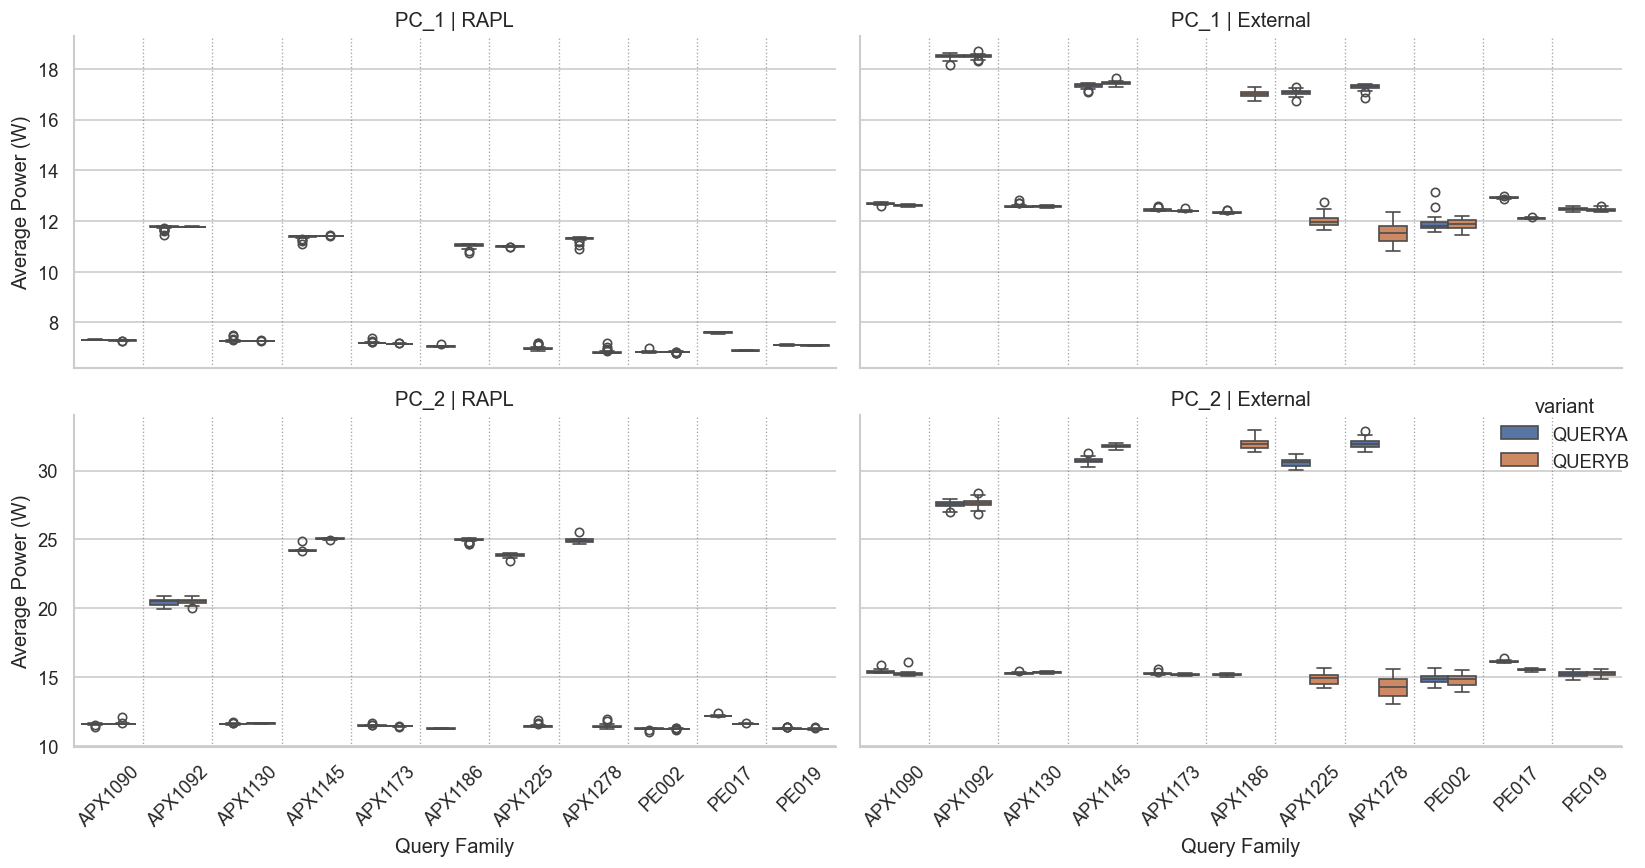

In [7]:
plot_df = analysis_df[analysis_df["variant"].isin(["QUERYA", "QUERYB"])].copy()
query_order = [q for q in pd.unique(plot_df["query_family"].dropna())]

def add_query_dividers(grid_or_axes, n_queries: int):
    if hasattr(grid_or_axes, "axes") and grid_or_axes.axes is not None:
        axes = np.array(grid_or_axes.axes).ravel()
    elif isinstance(grid_or_axes, (list, tuple, np.ndarray)):
        axes = np.array(grid_or_axes).ravel()
    else:
        axes = np.array([grid_or_axes])

    for ax in axes:
        if ax is None:
            continue
        for i in range(n_queries - 1):
            ax.axvline(i + 0.5, linestyle=":", color="gray", linewidth=0.8, alpha=0.7)

# Average Power plot: A/B side-by-side with both RAPL and External shown.
avg_long = plot_df.melt(
    id_vars=["pc", "query_family", "variant"],
    value_vars=["rapl_avg_power_w", "external_avg_power_w"],
    var_name="source_metric",
    value_name="avg_power_w",
)
avg_long["source"] = avg_long["source_metric"].map({
    "rapl_avg_power_w": "RAPL",
    "external_avg_power_w": "External",
})
avg_long = avg_long.dropna(subset=["avg_power_w", "query_family", "variant", "source"] )

if avg_long.empty:
    print("No data available for average-power plotting.")
else:
    g = sns.catplot(
        data=avg_long,
        x="query_family",
        y="avg_power_w",
        hue="variant",
        row="pc",
        col="source",
        row_order=["PC_1", "PC_2"],
        col_order=["RAPL", "External"],
        order=query_order,
        kind="box",
        height=3.7,
        aspect=1.7,
        sharey="row",
    )
    g.set_axis_labels("Query Family", "Average Power (W)")
    g.set_titles(row_template="{row_name}", col_template="{col_name}")
    for ax in g.axes.flat:
        ax.tick_params(axis="x", rotation=45)
    add_query_dividers(g, len(query_order))
    plt.tight_layout()
    plt.show()

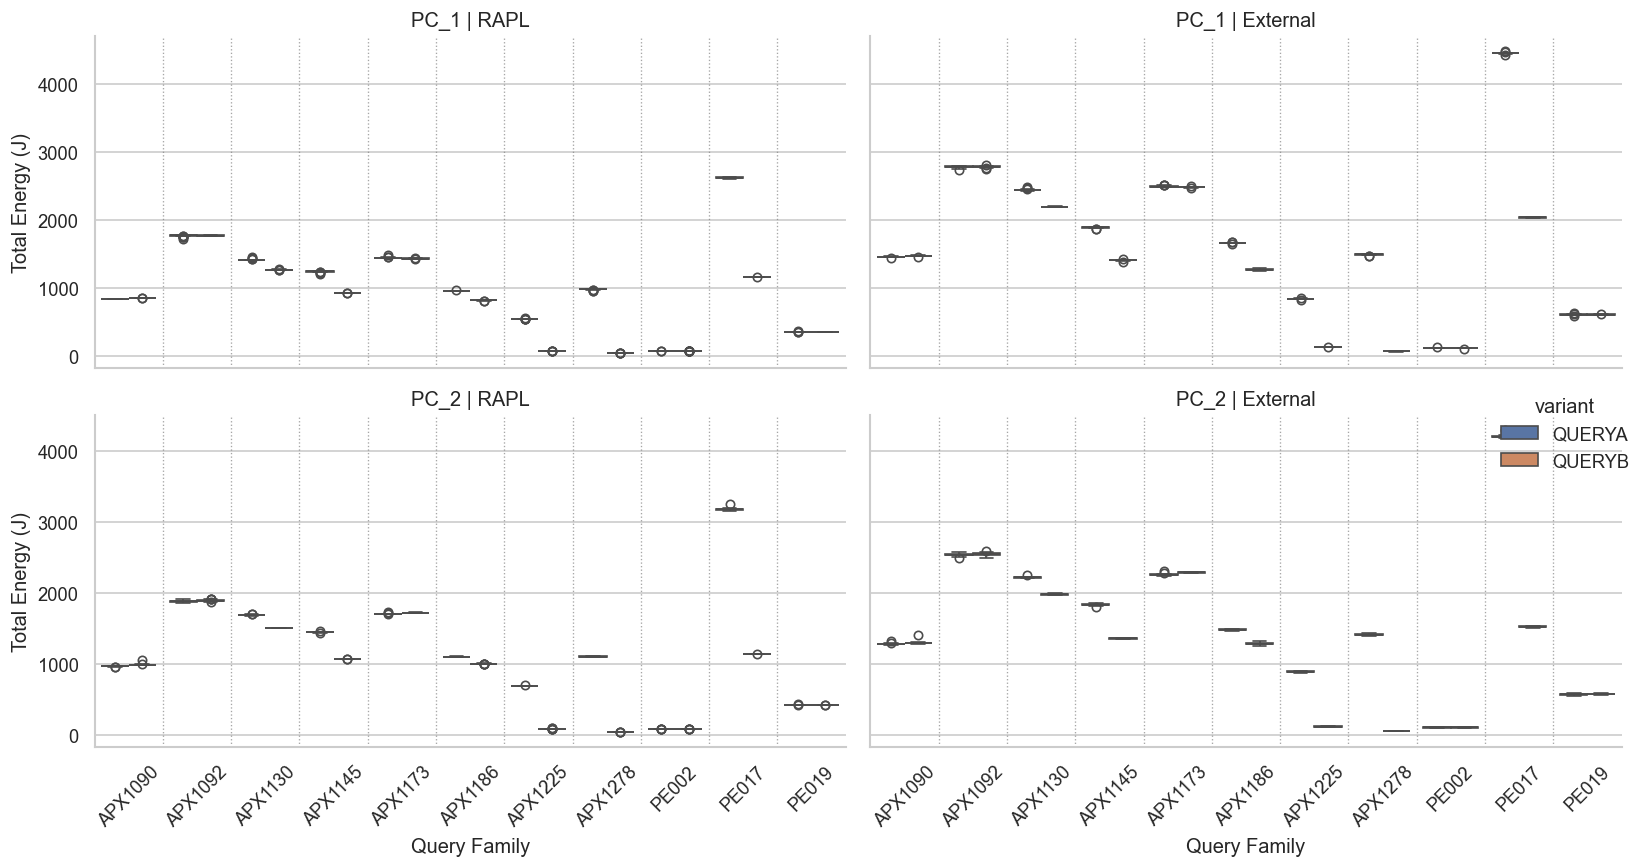

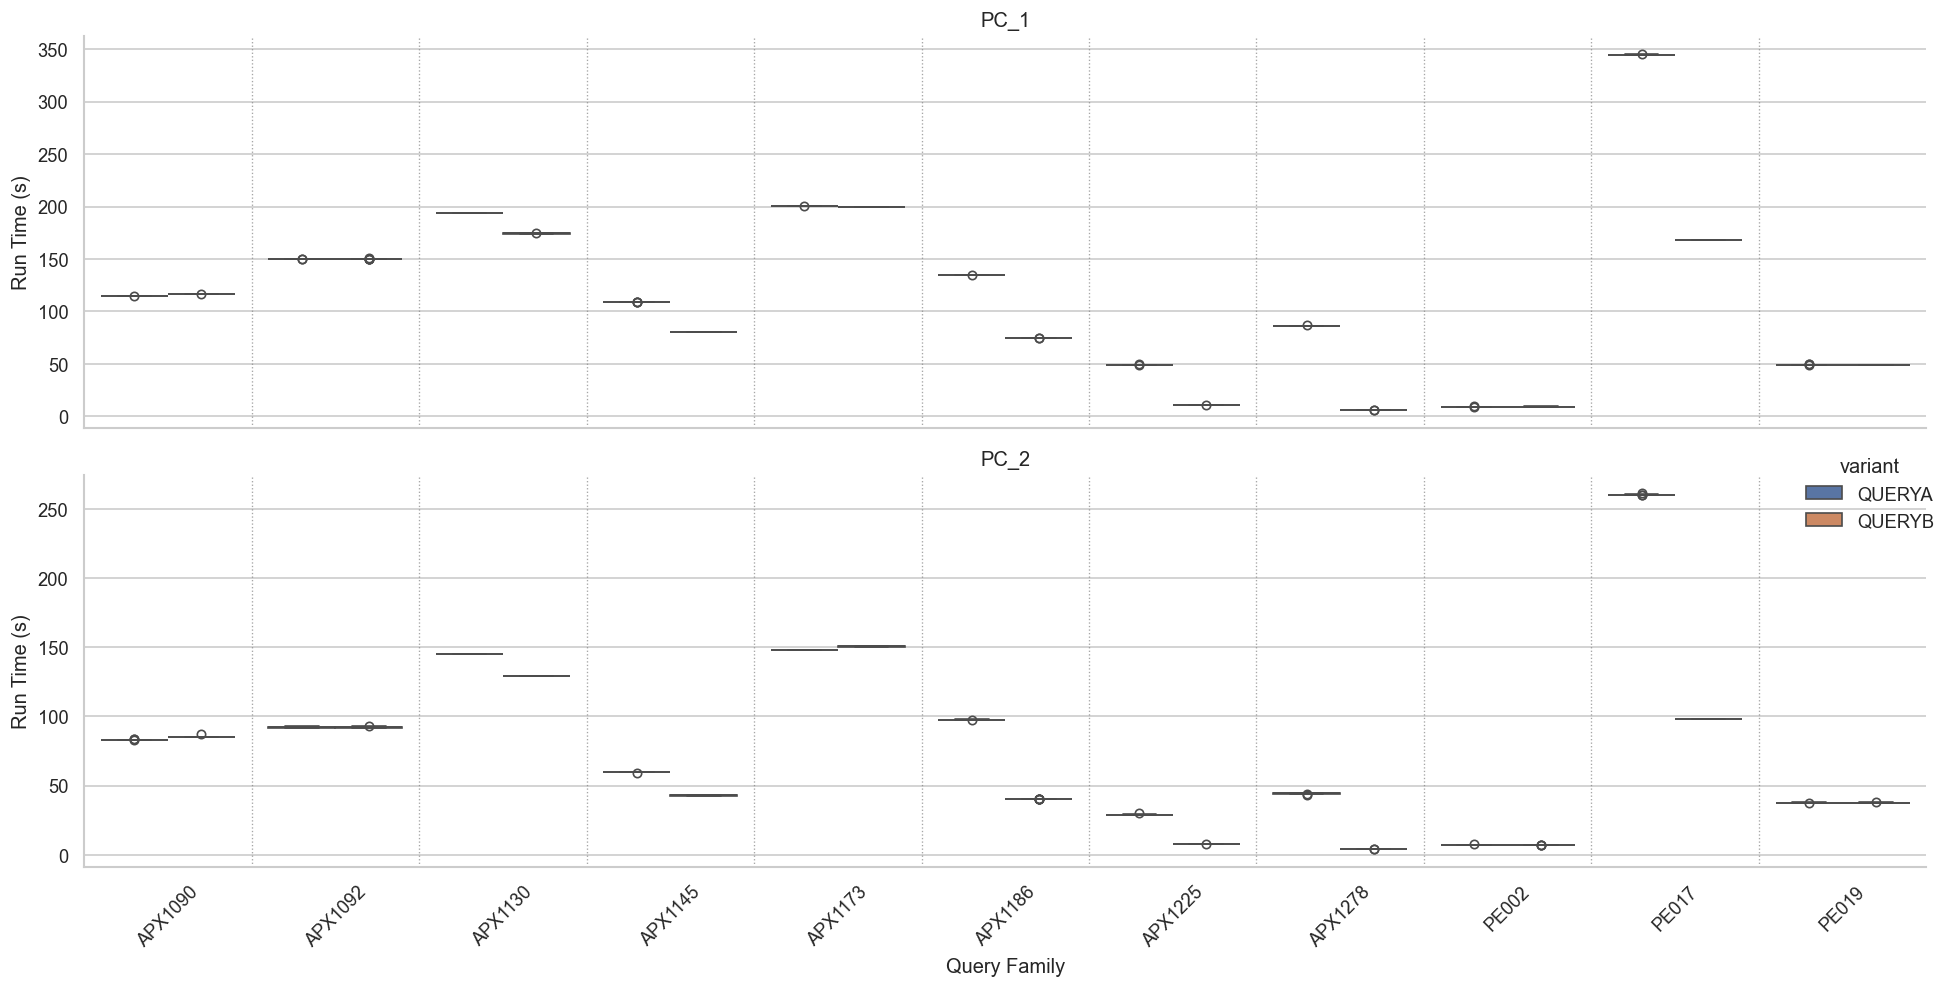

In [8]:
# Total Energy plot: A/B side-by-side with both RAPL and External shown.
energy_long = plot_df.melt(
    id_vars=["pc", "query_family", "variant"],
    value_vars=["rapl_package_j", "external_energy_j"],
    var_name="source_metric",
    value_name="energy_j",
)
energy_long["source"] = energy_long["source_metric"].map({
    "rapl_package_j": "RAPL",
    "external_energy_j": "External",
})
energy_long = energy_long.dropna(subset=["energy_j", "query_family", "variant", "source"] )

if energy_long.empty:
    print("No data available for energy plotting.")
else:
    g = sns.catplot(
        data=energy_long,
        x="query_family",
        y="energy_j",
        hue="variant",
        row="pc",
        col="source",
        row_order=["PC_1", "PC_2"],
        col_order=["RAPL", "External"],
        order=query_order,
        kind="box",
        height=3.7,
        aspect=1.7,
        sharey="row",
    )
    g.set_axis_labels("Query Family", "Total Energy (J)")
    g.set_titles(row_template="{row_name}", col_template="{col_name}")
    for ax in g.axes.flat:
        ax.tick_params(axis="x", rotation=45)
    add_query_dividers(g, len(query_order))
    plt.tight_layout()
    plt.show()

# Runtime plot: A/B side-by-side per query family and PC.
runtime_df = plot_df.dropna(subset=["total_elapsed_sec", "query_family", "variant"] )

if runtime_df.empty:
    print("No data available for runtime plotting.")
else:
    g = sns.catplot(
        data=runtime_df,
        x="query_family",
        y="total_elapsed_sec",
        hue="variant",
        row="pc",
        row_order=["PC_1", "PC_2"],
        order=query_order,
        kind="box",
        height=4.2,
        aspect=3.6,
        sharey=False,
    )
    g.set_axis_labels("Query Family", "Run Time (s)")
    g.set_titles(row_template="{row_name}")
    for ax in g.axes.flat:
        ax.tick_params(axis="x", rotation=45)
    add_query_dividers(g, len(query_order))
    plt.tight_layout()
    plt.show()

In [9]:
def ab_test_by_family(df: pd.DataFrame, value_col: str, metric_label: str, pc_name: str) -> list:
    rows = []
    fam_df = df[df["variant"].isin(["QUERYA", "QUERYB"]) & df["query_family"].notna()].copy()

    for family, g in fam_df.groupby("query_family"):
        a = g.loc[g["variant"] == "QUERYA", value_col].dropna().to_numpy()
        b = g.loc[g["variant"] == "QUERYB", value_col].dropna().to_numpy()

        n_a, n_b = len(a), len(b)
        if n_a < 2 or n_b < 2:
            continue

        shapiro_p_a = shapiro(a).pvalue if n_a >= 3 else np.nan
        shapiro_p_b = shapiro(b).pvalue if n_b >= 3 else np.nan
        normal_a = bool(shapiro_p_a > 0.05) if n_a >= 3 else False
        normal_b = bool(shapiro_p_b > 0.05) if n_b >= 3 else False

        if normal_a and normal_b:
            test_used = "welch_ttest"
            p_value = ttest_ind(a, b, equal_var=False).pvalue
            effect = (np.mean(a) - np.mean(b)) / np.sqrt(((np.var(a, ddof=1) + np.var(b, ddof=1)) / 2)) if n_a > 1 and n_b > 1 else np.nan
            effect_label = "std_mean_diff_A_minus_B"
        else:
            test_used = "mannwhitney_u"
            u = mannwhitneyu(a, b, alternative="two-sided").statistic
            p_value = mannwhitneyu(a, b, alternative="two-sided").pvalue
            effect = (2 * u / (n_a * n_b)) - 1
            effect_label = "rank_biserial_A_minus_B"

        rows.append({
            "pc": pc_name,
            "query_family": family,
            "metric": metric_label,
            "n_A": n_a,
            "n_B": n_b,
            "A_mean": float(np.mean(a)),
            "B_mean": float(np.mean(b)),
            "A_minus_B_mean": float(np.mean(a) - np.mean(b)),
            "A_vs_B_mean_pct": float(100 * (np.mean(a) - np.mean(b)) / np.mean(b)) if np.mean(b) != 0 else np.nan,
            "shapiro_p_A": shapiro_p_a,
            "shapiro_p_B": shapiro_p_b,
            "test_used": test_used,
            "p_value": p_value,
            "significant_0_05": bool(p_value < 0.05),
            "effect_label": effect_label,
            "effect_size": effect,
        })

    return rows


metrics_for_tests = [
    ("rapl_avg_power_w", "avg_power_rapl_w"),
    ("external_avg_power_w", "avg_power_external_w"),
    ("rapl_package_j", "energy_rapl_j"),
    ("external_energy_j", "energy_external_j"),
    ("total_elapsed_sec", "runtime_sec"),
]

stat_rows = []
for pc_name, payload in per_pc.items():
    mdf = payload["merged"]
    for col, label in metrics_for_tests:
        if col in mdf.columns:
            stat_rows.extend(ab_test_by_family(mdf, col, label, pc_name))

stats_df = pd.DataFrame(stat_rows)

if stats_df.empty:
    print("No family-level A/B statistical comparisons could be computed.")
else:
    stats_df = stats_df.sort_values(["pc", "metric", "query_family"]).reset_index(drop=True)
    print("A/B statistical test results by PC and query family:")
    display(
        stats_df[[
            "pc", "query_family", "metric", "n_A", "n_B", "test_used", "p_value",
            "significant_0_05", "A_mean", "B_mean", "A_vs_B_mean_pct", "effect_label", "effect_size"
        ]]
    )

    print("Significant results (p < 0.05):")
    display(
        stats_df.loc[stats_df["significant_0_05"]].sort_values(["pc", "metric", "p_value"])[[
            "pc", "query_family", "metric", "test_used", "p_value",
            "A_mean", "B_mean", "A_vs_B_mean_pct", "effect_label", "effect_size"
        ]]
    )

A/B statistical test results by PC and query family:


,pc,query_family,metric,n_A,n_B,test_used,p_value,significant_0_05,A_mean,B_mean,A_vs_B_mean_pct,effect_label,effect_size
0,PC_1,APX1090,avg_power_external_w,35,35,welch_ttest,1.967881e-11,True,12.693162,12.625626,0.534913,std_mean_diff_A_minus_B,1.962074
1,PC_1,APX1092,avg_power_external_w,35,34,mannwhitney_u,9.282729e-01,False,18.491798,18.507593,-0.085344,rank_biserial_A_minus_B,-0.013445
2,PC_1,APX1130,avg_power_external_w,35,35,mannwhitney_u,4.312888e-01,False,12.586189,12.578264,0.063002,rank_biserial_A_minus_B,-0.110204
3,PC_1,APX1145,avg_power_external_w,35,35,mannwhitney_u,8.634218e-09,True,17.333165,17.439408,-0.609214,rank_biserial_A_minus_B,-0.800816
4,PC_1,APX1173,avg_power_external_w,35,34,mannwhitney_u,1.133202e-06,True,12.445301,12.408589,0.295861,rank_biserial_A_minus_B,0.682353
...,...,...,...,...,...,...,...,...,...,...,...,...,...
105,PC_2,APX1225,runtime_sec,35,35,mannwhitney_u,6.545501e-13,True,29.062341,7.941733,265.944595,rank_biserial_A_minus_B,1.000000
106,PC_2,APX1278,runtime_sec,35,35,mannwhitney_u,6.545501e-13,True,44.279798,4.097096,980.760636,rank_biserial_A_minus_B,1.000000
107,PC_2,PE002,runtime_sec,35,35,mannwhitney_u,5.031592e-01,False,7.197295,7.194774,0.035036,rank_biserial_A_minus_B,-0.093878
108,PC_2,PE017,runtime_sec,34,35,mannwhitney_u,9.648700e-13,True,260.529764,98.064152,165.672785,rank_biserial_A_minus_B,1.000000


Significant results (p < 0.05):


,pc,query_family,metric,test_used,p_value,A_mean,B_mean,A_vs_B_mean_pct,effect_label,effect_size
9,PC_1,PE017,avg_power_external_w,welch_ttest,9.008582e-85,12.917727,12.110456,6.665894,std_mean_diff_A_minus_B,34.135222
6,PC_1,APX1225,avg_power_external_w,welch_ttest,2.619412e-58,17.063767,12.002712,42.165930,std_mean_diff_A_minus_B,26.716542
5,PC_1,APX1186,avg_power_external_w,mannwhitney_u,6.545501e-13,12.331630,17.009239,-27.500403,rank_biserial_A_minus_B,-1.000000
7,PC_1,APX1278,avg_power_external_w,mannwhitney_u,6.545501e-13,17.295699,11.546609,49.790288,rank_biserial_A_minus_B,1.000000
0,PC_1,APX1090,avg_power_external_w,welch_ttest,1.967881e-11,12.693162,12.625626,0.534913,std_mean_diff_A_minus_B,1.962074
...,...,...,...,...,...,...,...,...,...,...
102,PC_2,APX1145,runtime_sec,mannwhitney_u,6.545501e-13,59.765785,42.839042,39.512423,rank_biserial_A_minus_B,1.000000
104,PC_2,APX1186,runtime_sec,mannwhitney_u,6.545501e-13,97.767111,40.245982,142.923905,rank_biserial_A_minus_B,1.000000
105,PC_2,APX1225,runtime_sec,mannwhitney_u,6.545501e-13,29.062341,7.941733,265.944595,rank_biserial_A_minus_B,1.000000
106,PC_2,APX1278,runtime_sec,mannwhitney_u,6.545501e-13,44.279798,4.097096,980.760636,rank_biserial_A_minus_B,1.000000


In [10]:
# Cross-PC rank test: compare ranking of family-level A-B effects between PCs.
# Also includes a filtered Spearman test on families where |A-B|/B > 10% in external energy.
rank_rows = []


def get_energy_filter_families_for_rank(per_pc_dict: dict, threshold_pct: float = 10.0):
    keep = set()

    for pc_name, payload in per_pc_dict.items():
        mdf = payload["merged"]
        if "external_energy_j" not in mdf.columns:
            continue

        subset = mdf[mdf["variant"].isin(["QUERYA", "QUERYB"]) & mdf["query_family"].notna()].copy()
        fam = subset.groupby(["query_family", "variant"])["external_energy_j"].median().unstack()

        if not {"QUERYA", "QUERYB"}.issubset(fam.columns):
            continue

        fam = fam.dropna(subset=["QUERYA", "QUERYB"]).copy()
        fam["ab_energy_diff_pct"] = np.where(
            fam["QUERYB"] != 0,
            (fam["QUERYA"] - fam["QUERYB"]) / fam["QUERYB"] * 100,
            np.nan,
        )

        qualifying = fam.index[fam["ab_energy_diff_pct"].abs() > threshold_pct]
        keep.update(list(qualifying))

    return keep


energy_filter_families_for_rank = get_energy_filter_families_for_rank(per_pc, threshold_pct=10.0)

for col, label in metrics_for_tests:
    per_pc_effect = []
    for pc_name, payload in per_pc.items():
        mdf = payload["merged"]
        subset = mdf[mdf["variant"].isin(["QUERYA", "QUERYB"]) & mdf["query_family"].notna()].copy()
        fam = subset.groupby(["query_family", "variant"])[col].median().unstack()
        if "QUERYA" in fam.columns and "QUERYB" in fam.columns:
            fam = fam.dropna(subset=["QUERYA", "QUERYB"]).copy()
            fam["delta_A_minus_B"] = fam["QUERYA"] - fam["QUERYB"]
            fam = fam[["delta_A_minus_B"]].rename(columns={"delta_A_minus_B": pc_name})
            per_pc_effect.append(fam)

    if len(per_pc_effect) < 2:
        continue

    joined = per_pc_effect[0]
    for other in per_pc_effect[1:]:
        joined = joined.join(other, how="inner")

    if {"PC_1", "PC_2"}.issubset(joined.columns) and len(joined) >= 3:
        rho, p = spearmanr(joined["PC_1"], joined["PC_2"])

        filtered_joined = joined.loc[joined.index.intersection(list(energy_filter_families_for_rank))].copy()
        filtered_n = len(filtered_joined)

        if filtered_n >= 3:
            f_rho, f_p = spearmanr(filtered_joined["PC_1"], filtered_joined["PC_2"])
            f_same_signal = bool((f_rho > 0) and (f_p < 0.05))
            f_note = "ok"
        else:
            f_rho, f_p = np.nan, np.nan
            f_same_signal = False
            f_note = "insufficient_filtered_families"

        rank_rows.append({
            "metric": label,
            "n_query_families": int(len(joined)),
            "spearman_rho": float(rho),
            "p_value": float(p),
            "same_ranking_signal": bool((rho > 0) and (p < 0.05)),
            "filtered_n_query_families": int(filtered_n),
            "filtered_spearman_rho": float(f_rho) if not np.isnan(f_rho) else np.nan,
            "filtered_p_value": float(f_p) if not np.isnan(f_p) else np.nan,
            "filtered_same_ranking_signal": f_same_signal,
            "filtered_note": f_note,
        })

rank_df = pd.DataFrame(rank_rows)

if rank_df.empty:
    print("Not enough overlap to run cross-PC rank tests.")
else:
    print("Cross-PC rank agreement test (Spearman) on family-level A-B deltas:")
    print("Includes filtered Spearman result for families with |A-B|/B > 10% in external energy.")
    display(rank_df.sort_values("metric"))

# External vs RAPL rank test: within each PC and query variant, compare family rankings
# between external energy and RAPL package energy.
ext_rapl_rank_rows = []

for pc_name, payload in per_pc.items():
    mdf = payload["merged"]
    required_cols = {"query_family", "variant", "external_energy_j", "rapl_package_j"}
    if not required_cols.issubset(set(mdf.columns)):
        continue

    subset = mdf[
        mdf["variant"].isin(["QUERYA", "QUERYB"]) &
        mdf["query_family"].notna()
    ].copy()

    for variant in ["QUERYA", "QUERYB"]:
        variant_df = subset[subset["variant"] == variant].copy()
        fam = variant_df.groupby("query_family")[["external_energy_j", "rapl_package_j"]].median().dropna()
        n_fam = int(len(fam))

        if n_fam >= 3:
            rho, p = spearmanr(fam["external_energy_j"], fam["rapl_package_j"])
            note = "ok"
            same_signal = bool((rho > 0) and (p < 0.05))
            rho_val = float(rho)
            p_val = float(p)
        else:
            rho_val = np.nan
            p_val = np.nan
            same_signal = False
            note = "insufficient_families"

        ext_rapl_rank_rows.append({
            "pc": pc_name,
            "query": variant,
            "n_query_families": n_fam,
            "spearman_rho": rho_val,
            "p_value": p_val,
            "same_ranking_signal": same_signal,
            "note": note,
        })

ext_rapl_rank_df = pd.DataFrame(ext_rapl_rank_rows)

if ext_rapl_rank_df.empty:
    print("Not enough overlap to run external-vs-RAPL rank tests.")
else:
    print("External vs RAPL rank agreement test (Spearman) by PC and query variant:")
    display(ext_rapl_rank_df.sort_values(["pc", "query"]))


Cross-PC rank agreement test (Spearman) on family-level A-B deltas:
Includes filtered Spearman result for families with |A-B|/B > 10% in external energy.


,metric,n_query_families,spearman_rho,p_value,same_ranking_signal,filtered_n_query_families,filtered_spearman_rho,filtered_p_value,filtered_same_ranking_signal,filtered_note
1,avg_power_external_w,11,0.918182,0.000067,True,6,1.000000,0.000000,True,ok
0,avg_power_rapl_w,11,0.918182,0.000067,True,6,0.942857,0.004805,True,ok
3,energy_external_j,11,0.872727,0.000455,True,6,0.942857,0.004805,True,ok
2,energy_rapl_j,11,0.881818,0.000330,True,6,1.000000,0.000000,True,ok
4,runtime_sec,11,0.872727,0.000455,True,6,0.942857,0.004805,True,ok


External vs RAPL rank agreement test (Spearman) by PC and query variant:


,pc,query,n_query_families,spearman_rho,p_value,same_ranking_signal,note
0,PC_1,QUERYA,11,0.990909,3.762572e-09,True,ok
1,PC_1,QUERYB,11,0.990909,3.762572e-09,True,ok
2,PC_2,QUERYA,11,1.000000,0.000000e+00,True,ok
3,PC_2,QUERYB,11,0.990909,3.762572e-09,True,ok


In [11]:
# External vs RAPL on A/B family deltas: do both methods rank family-level A/B effects similarly?
ab_ext_vs_rapl_rank_rows = []

for pc_name, payload in per_pc.items():
    mdf = payload["merged"]
    required_cols = {"query_family", "variant", "external_energy_j", "rapl_package_j"}
    if not required_cols.issubset(set(mdf.columns)):
        continue

    subset = mdf[
        mdf["variant"].isin(["QUERYA", "QUERYB"]) &
        mdf["query_family"].notna()
    ].copy()

    # Family-level A/B deltas for each measurement source
    ext_fam = subset.groupby(["query_family", "variant"])["external_energy_j"].median().unstack()
    rapl_fam = subset.groupby(["query_family", "variant"])["rapl_package_j"].median().unstack()

    if not {"QUERYA", "QUERYB"}.issubset(ext_fam.columns) or not {"QUERYA", "QUERYB"}.issubset(rapl_fam.columns):
        continue

    ext_fam = ext_fam.dropna(subset=["QUERYA", "QUERYB"]).copy()
    rapl_fam = rapl_fam.dropna(subset=["QUERYA", "QUERYB"]).copy()

    ext_fam["external_delta_A_minus_B"] = ext_fam["QUERYA"] - ext_fam["QUERYB"]
    rapl_fam["rapl_delta_A_minus_B"] = rapl_fam["QUERYA"] - rapl_fam["QUERYB"]

    joined = ext_fam[["external_delta_A_minus_B"]].join(
        rapl_fam[["rapl_delta_A_minus_B"]],
        how="inner"
    ).dropna()

    n_fam = int(len(joined))
    if n_fam >= 3:
        rho, p = spearmanr(joined["external_delta_A_minus_B"], joined["rapl_delta_A_minus_B"])
        note = "ok"
        same_signal = bool((rho > 0) and (p < 0.05))
        rho_val = float(rho)
        p_val = float(p)
    else:
        rho_val = np.nan
        p_val = np.nan
        same_signal = False
        note = "insufficient_families"

    # Median signed offset of A/B deltas across families
    median_delta_offset_j = float(np.median(
        joined["external_delta_A_minus_B"] - joined["rapl_delta_A_minus_B"]
    )) if n_fam > 0 else np.nan

    ab_ext_vs_rapl_rank_rows.append({
        "pc": pc_name,
        "n_query_families": n_fam,
        "spearman_rho": rho_val,
        "p_value": p_val,
        "same_ranking_signal": same_signal,
        "median_external_minus_rapl_delta_j": median_delta_offset_j,
        "note": note,
    })

ab_ext_vs_rapl_rank_df = pd.DataFrame(ab_ext_vs_rapl_rank_rows)

if ab_ext_vs_rapl_rank_df.empty:
    print("Not enough overlap to run external-vs-RAPL A/B-delta rank tests.")
else:
    print("External vs RAPL rank agreement on family-level A/B deltas (QUERYA - QUERYB), by PC:")
    display(ab_ext_vs_rapl_rank_df.sort_values("pc"))


External vs RAPL rank agreement on family-level A/B deltas (QUERYA - QUERYB), by PC:


,pc,n_query_families,spearman_rho,p_value,same_ranking_signal,median_external_minus_rapl_delta_j,note
0,PC_1,11,0.981818,8.403066e-08,True,103.817240,ok
1,PC_2,11,0.990909,3.762572e-09,True,55.587302,ok


In [12]:
from scipy.stats import wilcoxon

# Cross-PC consistency test: are A/B deltas similar between PCs?
# Uses Wilcoxon signed-rank on paired family-level deltas: (QUERYA - QUERYB) in PC_1 vs PC_2.
# Also reports a second statistic on a filtered subset: families where |A-B|/B > 10% for external energy.


def run_paired_wilcoxon(x: pd.Series, y: pd.Series):
    d = (x - y).to_numpy()
    if len(d) == 0:
        return np.nan, np.nan, "no_pairs"
    if np.allclose(d, 0):
        return np.nan, np.nan, "all_paired_differences_zero"

    res = wilcoxon(x, y, alternative="two-sided")
    return float(res.statistic), float(res.pvalue), "ok"


def get_energy_filter_families(per_pc_dict: dict, energy_col: str = "external_energy_j", threshold_pct: float = 10.0):
    keep = set()

    for pc_name, payload in per_pc_dict.items():
        mdf = payload["merged"]
        if energy_col not in mdf.columns:
            continue

        subset = mdf[mdf["variant"].isin(["QUERYA", "QUERYB"]) & mdf["query_family"].notna()].copy()
        fam = subset.groupby(["query_family", "variant"])[energy_col].median().unstack()

        if not {"QUERYA", "QUERYB"}.issubset(fam.columns):
            continue

        fam = fam.dropna(subset=["QUERYA", "QUERYB"]).copy()
        fam["ab_energy_diff_pct"] = np.where(
            fam["QUERYB"] != 0,
            (fam["QUERYA"] - fam["QUERYB"]) / fam["QUERYB"] * 100,
            np.nan,
        )

        qualifying = fam.index[fam["ab_energy_diff_pct"].abs() > threshold_pct]
        keep.update(list(qualifying))

    return keep


energy_filter_families = get_energy_filter_families(per_pc, energy_col="external_energy_j", threshold_pct=10.0)
consistency_rows = []

for col, label in metrics_for_tests:
    per_pc_delta = []

    for pc_name, payload in per_pc.items():
        mdf = payload["merged"]
        if col not in mdf.columns:
            continue

        subset = mdf[mdf["variant"].isin(["QUERYA", "QUERYB"]) & mdf["query_family"].notna()].copy()
        fam = subset.groupby(["query_family", "variant"])[col].median().unstack()

        if {"QUERYA", "QUERYB"}.issubset(fam.columns):
            fam = fam.dropna(subset=["QUERYA", "QUERYB"]).copy()
            fam["delta_A_minus_B"] = fam["QUERYA"] - fam["QUERYB"]
            per_pc_delta.append(fam[["delta_A_minus_B"]].rename(columns={"delta_A_minus_B": pc_name}))

    if len(per_pc_delta) < 2:
        continue

    joined = per_pc_delta[0]
    for other in per_pc_delta[1:]:
        joined = joined.join(other, how="inner")

    if not {"PC_1", "PC_2"}.issubset(joined.columns):
        continue

    joined = joined.dropna(subset=["PC_1", "PC_2"]).copy()
    n = len(joined)
    if n == 0:
        continue

    stat, p_value, note = run_paired_wilcoxon(joined["PC_1"], joined["PC_2"])

    # Second statistic on filtered families with >10% A/B external-energy difference.
    filtered_joined = joined.loc[joined.index.intersection(list(energy_filter_families))].copy()
    filtered_n = len(filtered_joined)

    if filtered_n == 0:
        f_stat, f_p_value, f_note = np.nan, np.nan, "no_families_pass_energy_filter"
        f_consistent = False
        f_median_diff = np.nan
    else:
        f_stat, f_p_value, f_note = run_paired_wilcoxon(filtered_joined["PC_1"], filtered_joined["PC_2"])
        f_consistent = bool((not np.isnan(f_p_value)) and (f_p_value >= 0.05))
        f_median_diff = float(np.median((filtered_joined["PC_1"] - filtered_joined["PC_2"]).to_numpy()))

    consistency_rows.append({
        "metric": label,
        "n_query_families": int(n),
        "pc1_delta_median": float(np.median(joined["PC_1"])),
        "pc2_delta_median": float(np.median(joined["PC_2"])),
        "median_of_paired_diff_pc1_minus_pc2": float(np.median((joined["PC_1"] - joined["PC_2"]).to_numpy())),
        "wilcoxon_statistic": stat,
        "p_value": p_value,
        "consistent_ab_delta_0_05": bool((not np.isnan(p_value)) and (p_value >= 0.05)),
        "note": note,
        "filtered_n_query_families": int(filtered_n),
        "filtered_median_of_paired_diff_pc1_minus_pc2": f_median_diff,
        "filtered_wilcoxon_statistic": f_stat,
        "filtered_p_value": f_p_value,
        "filtered_consistent_ab_delta_0_05": f_consistent,
        "filtered_note": f_note,
    })

consistency_df = pd.DataFrame(consistency_rows)

if consistency_df.empty:
    print("Not enough overlapping family deltas to run cross-PC Wilcoxon consistency tests.")
else:
    print("Wilcoxon signed-rank consistency test on family-level A/B deltas (PC_1 vs PC_2):")
    print("Second statistic uses only families where |A-B|/B > 10% in external energy (in either PC).")
    display(consistency_df.sort_values("metric"))

    print("Interpretation guide: p >= 0.05 means no evidence that PC_1 and PC_2 A/B deltas differ systematically.")

Wilcoxon signed-rank consistency test on family-level A/B deltas (PC_1 vs PC_2):
Second statistic uses only families where |A-B|/B > 10% in external energy (in either PC).


,metric,n_query_families,pc1_delta_median,pc2_delta_median,median_of_paired_diff_pc1_minus_pc2,wilcoxon_statistic,p_value,consistent_ab_delta_0_05,note,filtered_n_query_families,filtered_median_of_paired_diff_pc1_minus_pc2,filtered_wilcoxon_statistic,filtered_p_value,filtered_consistent_ab_delta_0_05,filtered_note
1,avg_power_external_w,11,0.014424,-0.000726,0.043475,29.0,0.764648,True,ok,6,0.135257,9.0,0.84375,True,ok
0,avg_power_rapl_w,11,0.006570,0.001459,0.010767,27.0,0.637695,True,ok,6,0.075662,9.0,0.84375,True,ok
3,energy_external_j,11,242.867045,199.577660,5.412067,20.0,0.278320,True,ok,6,8.387824,9.0,0.84375,True,ok
2,energy_rapl_j,11,126.166504,98.276550,-0.579224,18.0,0.206055,True,ok,6,-83.822845,1.0,0.06250,True,ok
4,runtime_sec,11,19.470920,15.992653,3.228593,6.0,0.013672,False,ok,6,12.789738,0.0,0.03125,False,ok


Interpretation guide: p >= 0.05 means no evidence that PC_1 and PC_2 A/B deltas differ systematically.


In [13]:
if not stats_df.empty:
    sig_counts = (
        stats_df.groupby(["pc", "metric"], as_index=False)["significant_0_05"]
        .sum()
        .rename(columns={"significant_0_05": "n_significant_families"})
    )
    print("Significant A/B families per PC and metric (p < 0.05):")
    display(sig_counts.sort_values(["pc", "metric"]))

if not rank_df.empty:
    print("Cross-PC rank agreement summary:")
    display(rank_df.sort_values("metric"))

Significant A/B families per PC and metric (p < 0.05):


,pc,metric,n_significant_families
0,PC_1,avg_power_external_w,7
1,PC_1,avg_power_rapl_w,9
2,PC_1,energy_external_j,8
3,PC_1,energy_rapl_j,8
4,PC_1,runtime_sec,9
5,PC_2,avg_power_external_w,8
6,PC_2,avg_power_rapl_w,8
7,PC_2,energy_external_j,9
8,PC_2,energy_rapl_j,9
9,PC_2,runtime_sec,8


Cross-PC rank agreement summary:


,metric,n_query_families,spearman_rho,p_value,same_ranking_signal,filtered_n_query_families,filtered_spearman_rho,filtered_p_value,filtered_same_ranking_signal,filtered_note
1,avg_power_external_w,11,0.918182,0.000067,True,6,1.000000,0.000000,True,ok
0,avg_power_rapl_w,11,0.918182,0.000067,True,6,0.942857,0.004805,True,ok
3,energy_external_j,11,0.872727,0.000455,True,6,0.942857,0.004805,True,ok
2,energy_rapl_j,11,0.881818,0.000330,True,6,1.000000,0.000000,True,ok
4,runtime_sec,11,0.872727,0.000455,True,6,0.942857,0.004805,True,ok


In [14]:
from scipy.stats import wilcoxon, mannwhitneyu

# Wilcoxon signed-rank between PCs on per-test mean energy.
# Assumption: compare PC_1 vs PC_2 using paired test_name means for external energy.
energy_col = "external_energy_j"
threshold_pct = 10.0


def build_pc_test_means(per_pc_dict: dict, value_col: str) -> pd.DataFrame:
    frames = []
    for pc_name, payload in per_pc_dict.items():
        mdf = payload["merged"]
        if value_col not in mdf.columns:
            continue
        means = (
            mdf.groupby("test_name", as_index=False)[value_col]
            .mean()
            .rename(columns={value_col: pc_name})
        )
        frames.append(means)

    if len(frames) < 2:
        return pd.DataFrame()

    out = frames[0]
    for f in frames[1:]:
        out = out.merge(f, on="test_name", how="inner")
    return out


def ab_energy_diff_pct_by_pc(per_pc_dict: dict, value_col: str) -> pd.DataFrame:
    rows = []
    for pc_name, payload in per_pc_dict.items():
        mdf = payload["merged"]
        if value_col not in mdf.columns:
            continue

        subset = mdf[mdf["variant"].isin(["QUERYA", "QUERYB"]) & mdf["query_family"].notna()].copy()
        fam = subset.groupby(["query_family", "variant"])[value_col].mean().unstack()

        if "QUERYA" not in fam.columns or "QUERYB" not in fam.columns:
            continue

        fam = fam.dropna(subset=["QUERYA", "QUERYB"]).copy()
        fam["ab_diff_pct"] = np.where(
            fam["QUERYB"] != 0,
            (fam["QUERYA"] - fam["QUERYB"]) / fam["QUERYB"] * 100,
            np.nan,
        )

        fam = fam.reset_index()[["query_family", "ab_diff_pct"]]
        fam["pc"] = pc_name
        rows.append(fam)

    if not rows:
        return pd.DataFrame()

    return pd.concat(rows, ignore_index=True)


paired_energy = build_pc_test_means(per_pc, energy_col)

if paired_energy.empty or not {"PC_1", "PC_2"}.issubset(paired_energy.columns):
    print(f"Could not build paired PC data for {energy_col}.")
else:
    paired_energy = paired_energy.dropna(subset=["PC_1", "PC_2"]).copy()

    if len(paired_energy) == 0:
        print("No overlapping tests with non-null energy means between PCs.")
    else:
        # Baseline Wilcoxon signed-rank over all paired test names.
        all_res = wilcoxon(paired_energy["PC_1"], paired_energy["PC_2"], alternative="two-sided")
        all_ranksum = mannwhitneyu(paired_energy["PC_1"], paired_energy["PC_2"], alternative="two-sided")

        print(f"Wilcoxon signed-rank (all paired test names) for {energy_col}:")
        print(f"n_pairs = {len(paired_energy)}")
        print(f"statistic = {all_res.statistic:.6g}, p_value = {all_res.pvalue:.6g}")

        print("Wilcoxon rank-sum (Mann-Whitney U, all paired test names as two samples):")
        print(f"n_PC1 = {len(paired_energy['PC_1'])}, n_PC2 = {len(paired_energy['PC_2'])}")
        print(f"statistic = {all_ranksum.statistic:.6g}, p_value = {all_ranksum.pvalue:.6g}")

        # Subset by |A/B mean difference| > threshold_pct.
        ab_diff = ab_energy_diff_pct_by_pc(per_pc, energy_col)

        if ab_diff.empty:
            print("Could not compute A/B mean energy differences for subset filtering.")
        else:
            # Keep families where either PC shows > threshold in absolute terms.
            fam_keep = (
                ab_diff.assign(abs_ab_diff_pct=ab_diff["ab_diff_pct"].abs())
                .groupby("query_family", as_index=False)["abs_ab_diff_pct"]
                .max()
            )
            fam_keep = fam_keep.loc[fam_keep["abs_ab_diff_pct"] > threshold_pct, "query_family"]

            filtered = paired_energy.copy()
            filtered["query_family"] = filtered["test_name"].str.replace(r"-query[AB]\.sql$", "", regex=True)
            filtered = filtered[filtered["query_family"].isin(fam_keep)].drop(columns=["query_family"])

            print(
                f"\nFamilies passing |A/B mean energy diff| > {threshold_pct:.0f}%: {len(fam_keep)}"
            )
            print(f"Paired test names in filtered set: {len(filtered)}")

            if len(filtered) == 0:
                print("No paired tests left after filtering.")
            elif np.allclose(filtered["PC_1"].to_numpy(), filtered["PC_2"].to_numpy()):
                print("Filtered paired energies are identical between PCs; Wilcoxon signed-rank is undefined.")
                filt_ranksum = mannwhitneyu(filtered["PC_1"], filtered["PC_2"], alternative="two-sided")
                print("Wilcoxon rank-sum (Mann-Whitney U, filtered set):")
                print(f"statistic = {filt_ranksum.statistic:.6g}, p_value = {filt_ranksum.pvalue:.6g}")
            else:
                filt_res = wilcoxon(filtered["PC_1"], filtered["PC_2"], alternative="two-sided")
                filt_ranksum = mannwhitneyu(filtered["PC_1"], filtered["PC_2"], alternative="two-sided")
                print("Wilcoxon signed-rank (filtered set):")
                print(f"statistic = {filt_res.statistic:.6g}, p_value = {filt_res.pvalue:.6g}")
                print("Wilcoxon rank-sum (Mann-Whitney U, filtered set):")
                print(f"statistic = {filt_ranksum.statistic:.6g}, p_value = {filt_ranksum.pvalue:.6g}")

        # Optional inspection table
        display(paired_energy.sort_values("test_name").reset_index(drop=True))

Wilcoxon signed-rank (all paired test names) for external_energy_j:
n_pairs = 22
statistic = 14, p_value = 5.24521e-05
Wilcoxon rank-sum (Mann-Whitney U, all paired test names as two samples):
n_PC1 = 22, n_PC2 = 22
statistic = 266, p_value = 0.581218

Families passing |A/B mean energy diff| > 10%: 6
Paired test names in filtered set: 12
Wilcoxon signed-rank (filtered set):
statistic = 8, p_value = 0.012207
Wilcoxon rank-sum (Mann-Whitney U, filtered set):
statistic = 80, p_value = 0.665006


,test_name,PC_1,PC_2
0,APX1090-queryA.sql,1457.323859,1284.405541
1,APX1090-queryB.sql,1470.791058,1299.993331
2,APX1092-queryA.sql,2778.170282,2539.556328
3,APX1092-queryB.sql,2781.300487,2548.834858
4,APX1130-queryA.sql,2438.857194,2220.461145
5,APX1130-queryB.sql,2192.641337,1983.089417
6,APX1145-queryA.sql,1890.149171,1835.121305
7,APX1145-queryB.sql,1405.385498,1360.702264
8,APX1173-queryA.sql,2493.722196,2260.208520
9,APX1173-queryB.sql,2479.077212,2289.685515


In [15]:
# Compute RAPL offset for each test and PC
offset_rows = []

for pc_name, payload in per_pc.items():
    mdf = payload["merged"]
    
    # Group by test_name to get per-test metrics
    for test_name, group in mdf.groupby("test_name"):
        rapl_avg_power = group["rapl_avg_power_w"].median()
        external_avg_power = group["external_avg_power_w"].median()
        
        rapl_energy = group["rapl_package_j"].median()
        external_energy = group["external_energy_j"].median()
        
        # Calculate percentage offsets
        power_offset_pct = (rapl_avg_power - external_avg_power) / external_avg_power * 100 if pd.notna(external_avg_power) and external_avg_power != 0 else np.nan
        energy_offset_pct = (rapl_energy - external_energy) / external_energy * 100 if pd.notna(external_energy) and external_energy != 0 else np.nan
        
        # Parse query family and variant
        family, variant = parse_test_name(test_name)
        
        offset_rows.append({
            "pc": pc_name,
            "test_name": test_name,
            "query_family": family,
            "variant": variant,
            "rapl_avg_power_w": rapl_avg_power if pd.notna(rapl_avg_power) else np.nan,
            "external_avg_power_w": external_avg_power if pd.notna(external_avg_power) else np.nan,
            "power_offset_pct": power_offset_pct,
            "rapl_energy_j": rapl_energy if pd.notna(rapl_energy) else np.nan,
            "external_energy_j": external_energy if pd.notna(external_energy) else np.nan,
            "energy_offset_pct": energy_offset_pct,
            "n_runs": len(group),
        })

offset_df = pd.DataFrame(offset_rows)

if offset_df.empty:
    print("No offset data available.")
else:
    offset_df = offset_df.sort_values(["pc", "query_family", "variant"]).reset_index(drop=True)
    print("RAPL offset (% difference from external measurements) by test and PC:")
    display(offset_df[[
        "pc", "query_family", "variant", "test_name",
        "rapl_avg_power_w", "external_avg_power_w", "power_offset_pct",
        "rapl_energy_j", "external_energy_j", "energy_offset_pct", "n_runs"
    ]])


RAPL offset (% difference from external measurements) by test and PC:


,pc,query_family,variant,test_name,rapl_avg_power_w,external_avg_power_w,power_offset_pct,rapl_energy_j,external_energy_j,energy_offset_pct,n_runs
0,PC_1,APX1090,QUERYA,APX1090-queryA.sql,7.302836,12.690528,-42.454432,838.466919,1457.867915,-42.486771,35
1,PC_1,APX1090,QUERYB,APX1090-queryB.sql,7.290804,12.626516,-42.257996,849.679504,1471.499905,-42.257590,35
2,PC_1,APX1092,QUERYA,APX1092-queryA.sql,11.780478,18.522867,-36.400351,1769.904053,2782.227245,-36.385353,35
3,PC_1,APX1092,QUERYB,APX1092-queryB.sql,11.773909,18.515359,-36.410044,1769.432739,2782.350330,-36.405106,34
4,PC_1,APX1130,QUERYA,APX1130-queryA.sql,7.261987,12.571178,-42.233042,1407.154907,2435.576415,-42.224974,35
5,PC_1,APX1130,QUERYB,APX1130-queryB.sql,7.274757,12.577635,-42.161166,1268.105103,2192.709370,-42.167206,35
6,PC_1,APX1145,QUERYA,APX1145-queryA.sql,11.391039,17.352646,-34.355610,1241.896912,1892.099040,-34.364064,35
7,PC_1,APX1145,QUERYB,APX1145-queryB.sql,11.400618,17.448273,-34.660480,919.202698,1405.963850,-34.621171,35
8,PC_1,APX1173,QUERYA,APX1173-queryA.sql,7.192446,12.430701,-42.139657,1440.714233,2490.204985,-42.144753,35
9,PC_1,APX1173,QUERYB,APX1173-queryB.sql,7.161879,12.408257,-42.281343,1431.080353,2478.781997,-42.266793,34


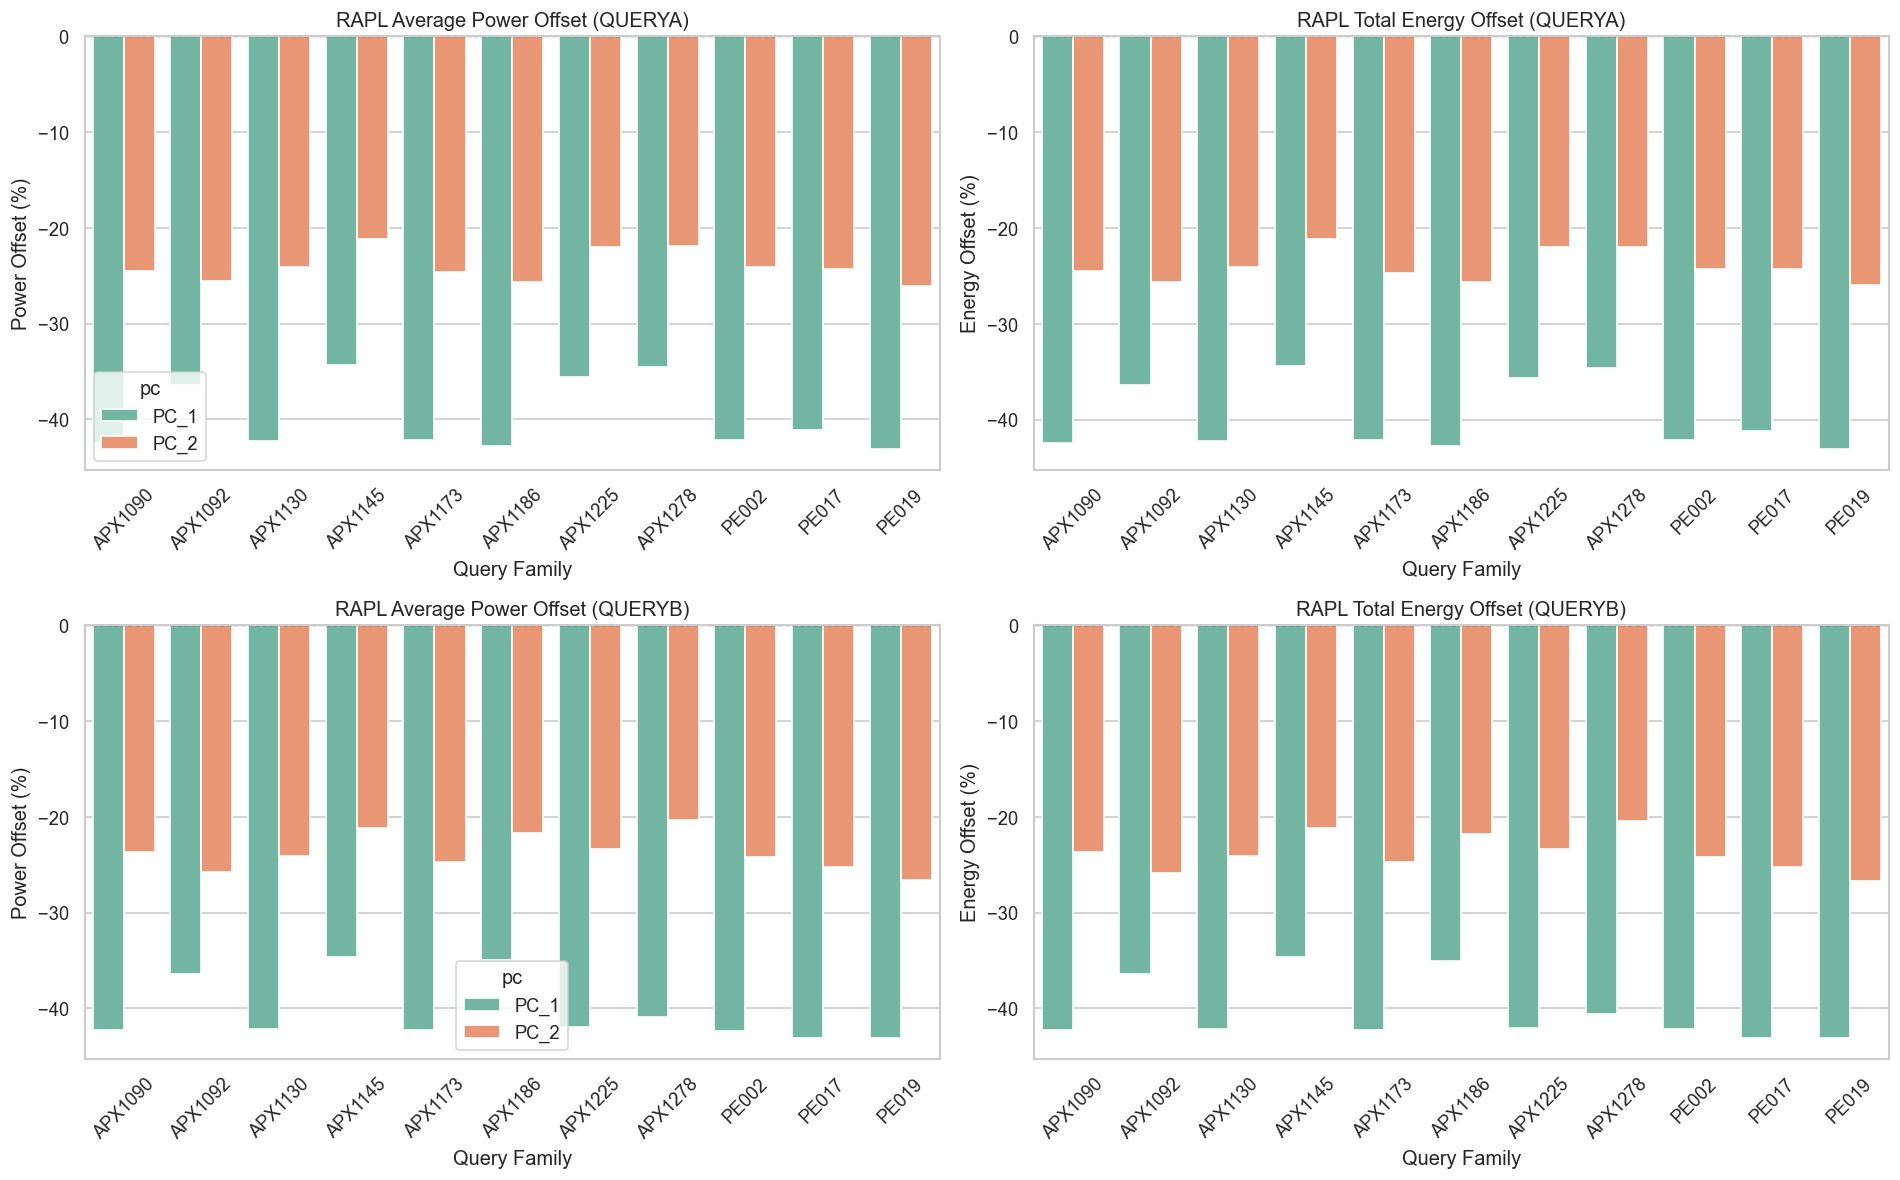


RAP offset summary by PC and variant:


power_offset_pct                                             \
                         mean     median        min        max       std   
variant pc                                                                 
QUERYA  PC_1       -39.719120 -42.095608 -43.091189 -34.355610  3.623918   
        PC_2       -23.992930 -24.276058 -26.032353 -21.154896  1.641244   
QUERYB  PC_1       -40.376171 -42.161166 -43.113571 -34.660480  3.306074   
        PC_2       -23.692002 -24.087413 -26.562462 -20.346078  1.946563   

             energy_offset_pct                                             
                          mean     median        min        max       std  
variant pc                                                                 
QUERYA  PC_1        -39.721248 -42.104315 -43.065224 -34.364064  3.618654  
        PC_2        -24.019042 -24.297478 -25.965394 -21.203567  1.616752  
QUERYB  PC_1        -40.341410 -42.167206 -43.115378 -34.621171  3.299726  
        PC_2        -23.737925 -24.099459 -26.675993 -20.413204  1.962779

In [16]:
# Visualize RAPL offsets by metric and PC, separated by variant (Query A vs B)
if not offset_df.empty:
    plot_offset = offset_df.dropna(subset=["power_offset_pct", "energy_offset_pct"]).copy()
    
    if not plot_offset.empty:
        fig, axes = plt.subplots(2, 2, figsize=(16, 10))
        
        # For each variant, create power and energy offset plots
        for idx, variant in enumerate(["QUERYA", "QUERYB"]):
            variant_data = plot_offset[plot_offset["variant"] == variant].sort_values(["pc", "query_family"])
            
            if variant_data.empty:
                continue
            
            # Power offset plot
            sns.barplot(
                data=variant_data,
                x="query_family", y="power_offset_pct", hue="pc",
                ax=axes[idx, 0], palette="Set2"
            )
            axes[idx, 0].set_title(f"RAPL Average Power Offset ({variant})")
            axes[idx, 0].set_ylabel("Power Offset (%)")
            axes[idx, 0].set_xlabel("Query Family")
            axes[idx, 0].axhline(0, color="black", linewidth=0.8, linestyle="--", alpha=0.5)
            axes[idx, 0].tick_params(axis="x", rotation=45)
            
            # Energy offset plot
            sns.barplot(
                data=variant_data,
                x="query_family", y="energy_offset_pct", hue="pc",
                ax=axes[idx, 1], palette="Set2"
            )
            axes[idx, 1].set_title(f"RAPL Total Energy Offset ({variant})")
            axes[idx, 1].set_ylabel("Energy Offset (%)")
            axes[idx, 1].set_xlabel("Query Family")
            axes[idx, 1].axhline(0, color="black", linewidth=0.8, linestyle="--", alpha=0.5)
            axes[idx, 1].tick_params(axis="x", rotation=45)
            axes[idx, 1].get_legend().remove()
        
        plt.tight_layout()
        plt.show()
        
        # Summary statistics
        print("\nRAP offset summary by PC and variant:")
        summary = offset_df.groupby(["variant", "pc"])[["power_offset_pct", "energy_offset_pct"]].agg([
            ("mean", "mean"),
            ("median", "median"),
            ("min", "min"),
            ("max", "max"),
            ("std", "std"),
        ])
        display(summary)


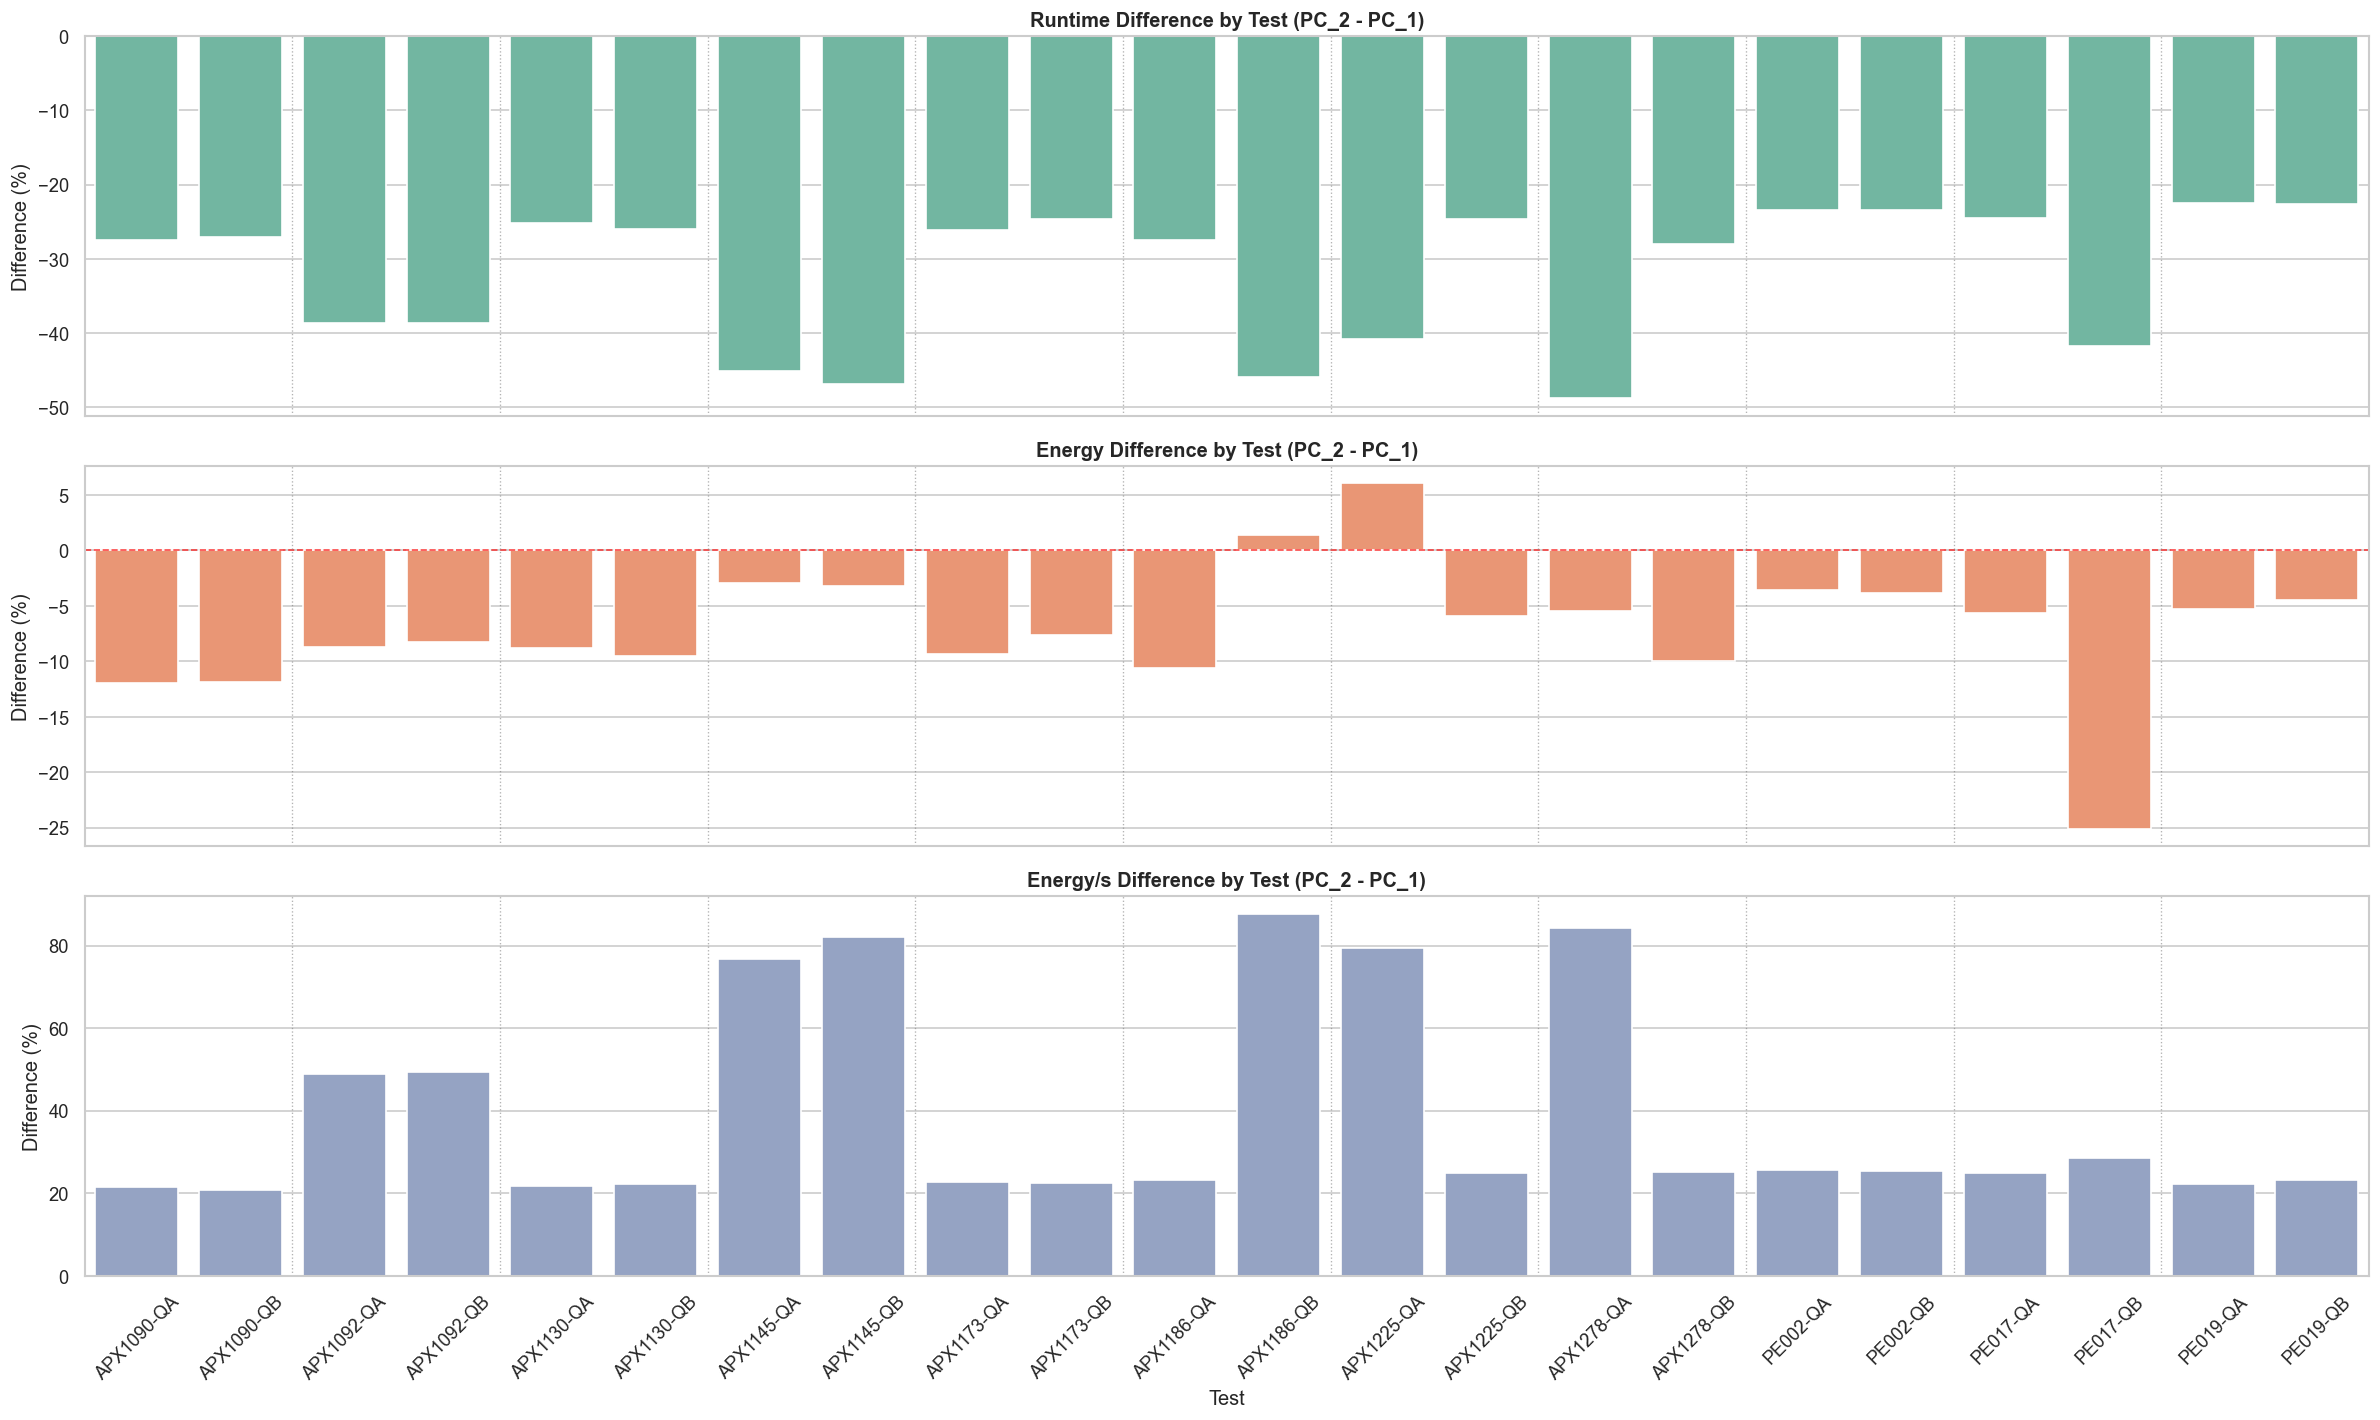

PC_1 vs PC_2 Comparison (median values by test):


,test_name,test_label,query_family,variant,pc1_runtime_sec,pc2_runtime_sec,runtime_diff_pct,pc1_energy_j,pc2_energy_j,energy_diff_pct,pc1_energy_per_sec,pc2_energy_per_sec,energy_per_sec_diff_pct
0,APX1090-queryA.sql,APX1090-QA,APX1090,QUERYA,114.798472,83.216858,-27.510483,1457.867915,1283.134960,-11.985513,12.690885,15.424885,21.543021
1,APX1090-queryB.sql,APX1090-QB,APX1090,QUERYB,116.559258,85.076148,-27.010390,1471.499905,1297.220825,-11.843635,12.625848,15.249136,20.777119
2,APX1092-queryA.sql,APX1092-QA,APX1092,QUERYA,150.237515,92.121016,-38.683081,2782.227245,2541.079910,-8.667421,18.518617,27.575990,48.909558
3,APX1092-queryB.sql,APX1092-QB,APX1092,QUERYB,150.282558,92.121403,-38.701201,2782.350330,2552.922335,-8.245834,18.514347,27.670400,49.453827
4,APX1130-queryA.sql,APX1130-QA,APX1130,QUERYA,193.786966,145.058610,-25.145322,2435.576415,2220.627797,-8.825369,12.570549,15.313201,21.818074
5,APX1130-queryB.sql,APX1130-QB,APX1130,QUERYB,174.316046,129.065957,-25.958648,2192.709370,1983.172820,-9.556057,12.577783,15.363057,22.144398
6,APX1145-queryA.sql,APX1145-QA,APX1145,QUERYA,109.042230,59.792459,-45.165778,1892.099040,1835.866630,-2.971959,17.353710,30.687633,76.836151
7,APX1145-queryB.sql,APX1145-QB,APX1145,QUERYB,80.622249,42.836260,-46.867942,1405.963850,1361.095020,-3.191322,17.437495,31.764789,82.163720
8,APX1173-queryA.sql,APX1173-QA,APX1173,QUERYA,200.348819,147.946886,-26.155349,2490.204985,2258.381140,-9.309428,12.430969,15.267271,22.816421
9,APX1173-queryB.sql,APX1173-QB,APX1173,QUERYB,199.811511,150.638171,-24.609863,2478.781997,2290.312665,-7.603304,12.405973,15.206252,22.572029


In [17]:
# PC_1 vs PC_2 comparison: Runtime, Energy, and Energy/s differences by test (query-level, not family-aggregated)
comparison_rows = []

for test_name in sorted(analysis_df["test_name"].dropna().unique()):
    pc1_data = analysis_df[(analysis_df["pc"] == "PC_1") & (analysis_df["test_name"] == test_name)]
    pc2_data = analysis_df[(analysis_df["pc"] == "PC_2") & (analysis_df["test_name"] == test_name)]

    if pc1_data.empty or pc2_data.empty:
        continue

    pc1_runtime = pc1_data["total_elapsed_sec"].median()
    pc2_runtime = pc2_data["total_elapsed_sec"].median()

    pc1_energy = pc1_data["external_energy_j"].median()
    pc2_energy = pc2_data["external_energy_j"].median()

    pc1_energy_per_sec = (
        (pc1_data["external_energy_j"] / pc1_data["total_elapsed_sec"])
        .replace([np.inf, -np.inf], np.nan)
        .dropna()
        .median()
    )
    pc2_energy_per_sec = (
        (pc2_data["external_energy_j"] / pc2_data["total_elapsed_sec"])
        .replace([np.inf, -np.inf], np.nan)
        .dropna()
        .median()
    )

    # Difference definition: PC_2 - PC_1
    runtime_diff_pct = (pc2_runtime - pc1_runtime) / pc1_runtime * 100 if pc1_runtime > 0 else np.nan
    energy_diff_pct = (pc2_energy - pc1_energy) / pc1_energy * 100 if pc1_energy > 0 else np.nan
    energy_per_sec_diff_pct = (
        (pc2_energy_per_sec - pc1_energy_per_sec) / pc1_energy_per_sec * 100
        if pd.notna(pc1_energy_per_sec) and pc1_energy_per_sec > 0
        else np.nan
    )

    family, variant = parse_test_name(test_name)
    variant_short = variant.replace("QUERY", "Q") if isinstance(variant, str) else ""
    test_label = f"{family}-{variant_short}" if family and variant_short else str(test_name)

    comparison_rows.append({
        "test_name": test_name,
        "test_label": test_label,
        "query_family": family,
        "variant": variant,
        "pc1_runtime_sec": pc1_runtime,
        "pc2_runtime_sec": pc2_runtime,
        "runtime_diff_pct": runtime_diff_pct,
        "pc1_energy_j": pc1_energy,
        "pc2_energy_j": pc2_energy,
        "energy_diff_pct": energy_diff_pct,
        "pc1_energy_per_sec": pc1_energy_per_sec,
        "pc2_energy_per_sec": pc2_energy_per_sec,
        "energy_per_sec_diff_pct": energy_per_sec_diff_pct,
    })

comparison_df = pd.DataFrame(comparison_rows)

if not comparison_df.empty:
    comparison_df = comparison_df.sort_values(["query_family", "variant"]).reset_index(drop=True)
    test_order = comparison_df["test_label"].tolist()

    fig, axes = plt.subplots(3, 1, figsize=(20, 12), sharex=True)

    # Runtime difference by individual test query
    sns.barplot(
        data=comparison_df,
        x="test_label",
        y="runtime_diff_pct",
        ax=axes[0],
        color="#66C2A5",
    )
    axes[0].set_title("Runtime Difference by Test (PC_2 - PC_1)", fontsize=12, fontweight="bold")
    axes[0].set_ylabel("Difference (%)")
    axes[0].set_xlabel("Test")
    axes[0].axhline(0, color="red", linewidth=1, linestyle="--", alpha=0.7)
    axes[0].tick_params(axis="x", rotation=45)

    # Energy difference by individual test query
    sns.barplot(
        data=comparison_df,
        x="test_label",
        y="energy_diff_pct",
        ax=axes[1],
        color="#FC8D62",
    )
    axes[1].set_title("Energy Difference by Test (PC_2 - PC_1)", fontsize=12, fontweight="bold")
    axes[1].set_ylabel("Difference (%)")
    axes[1].set_xlabel("Test")
    axes[1].axhline(0, color="red", linewidth=1, linestyle="--", alpha=0.7)
    axes[1].tick_params(axis="x", rotation=45)

    # Energy per second difference by individual test query
    sns.barplot(
        data=comparison_df,
        x="test_label",
        y="energy_per_sec_diff_pct",
        ax=axes[2],
        color="#8DA0CB",
    )
    axes[2].set_title("Energy/s Difference by Test (PC_2 - PC_1)", fontsize=12, fontweight="bold")
    axes[2].set_ylabel("Difference (%)")
    axes[2].set_xlabel("Test")
    axes[2].axhline(0, color="red", linewidth=1, linestyle="--", alpha=0.7)
    axes[2].tick_params(axis="x", rotation=45)

    # Visual separators between families (every 2 tests: A and B)
    for ax in axes:
        for i in range(1, len(test_order)):
            if i % 2 == 0:
                ax.axvline(i - 0.5, linestyle=":", color="gray", linewidth=0.8, alpha=0.6)

    plt.tight_layout()
    plt.show()

    print("PC_1 vs PC_2 Comparison (median values by test):")
    display(comparison_df[[
        "test_name", "test_label", "query_family", "variant",
        "pc1_runtime_sec", "pc2_runtime_sec", "runtime_diff_pct",
        "pc1_energy_j", "pc2_energy_j", "energy_diff_pct",
        "pc1_energy_per_sec", "pc2_energy_per_sec", "energy_per_sec_diff_pct"
    ]])

Saved: plots\ab_significance_tables_combined.svg


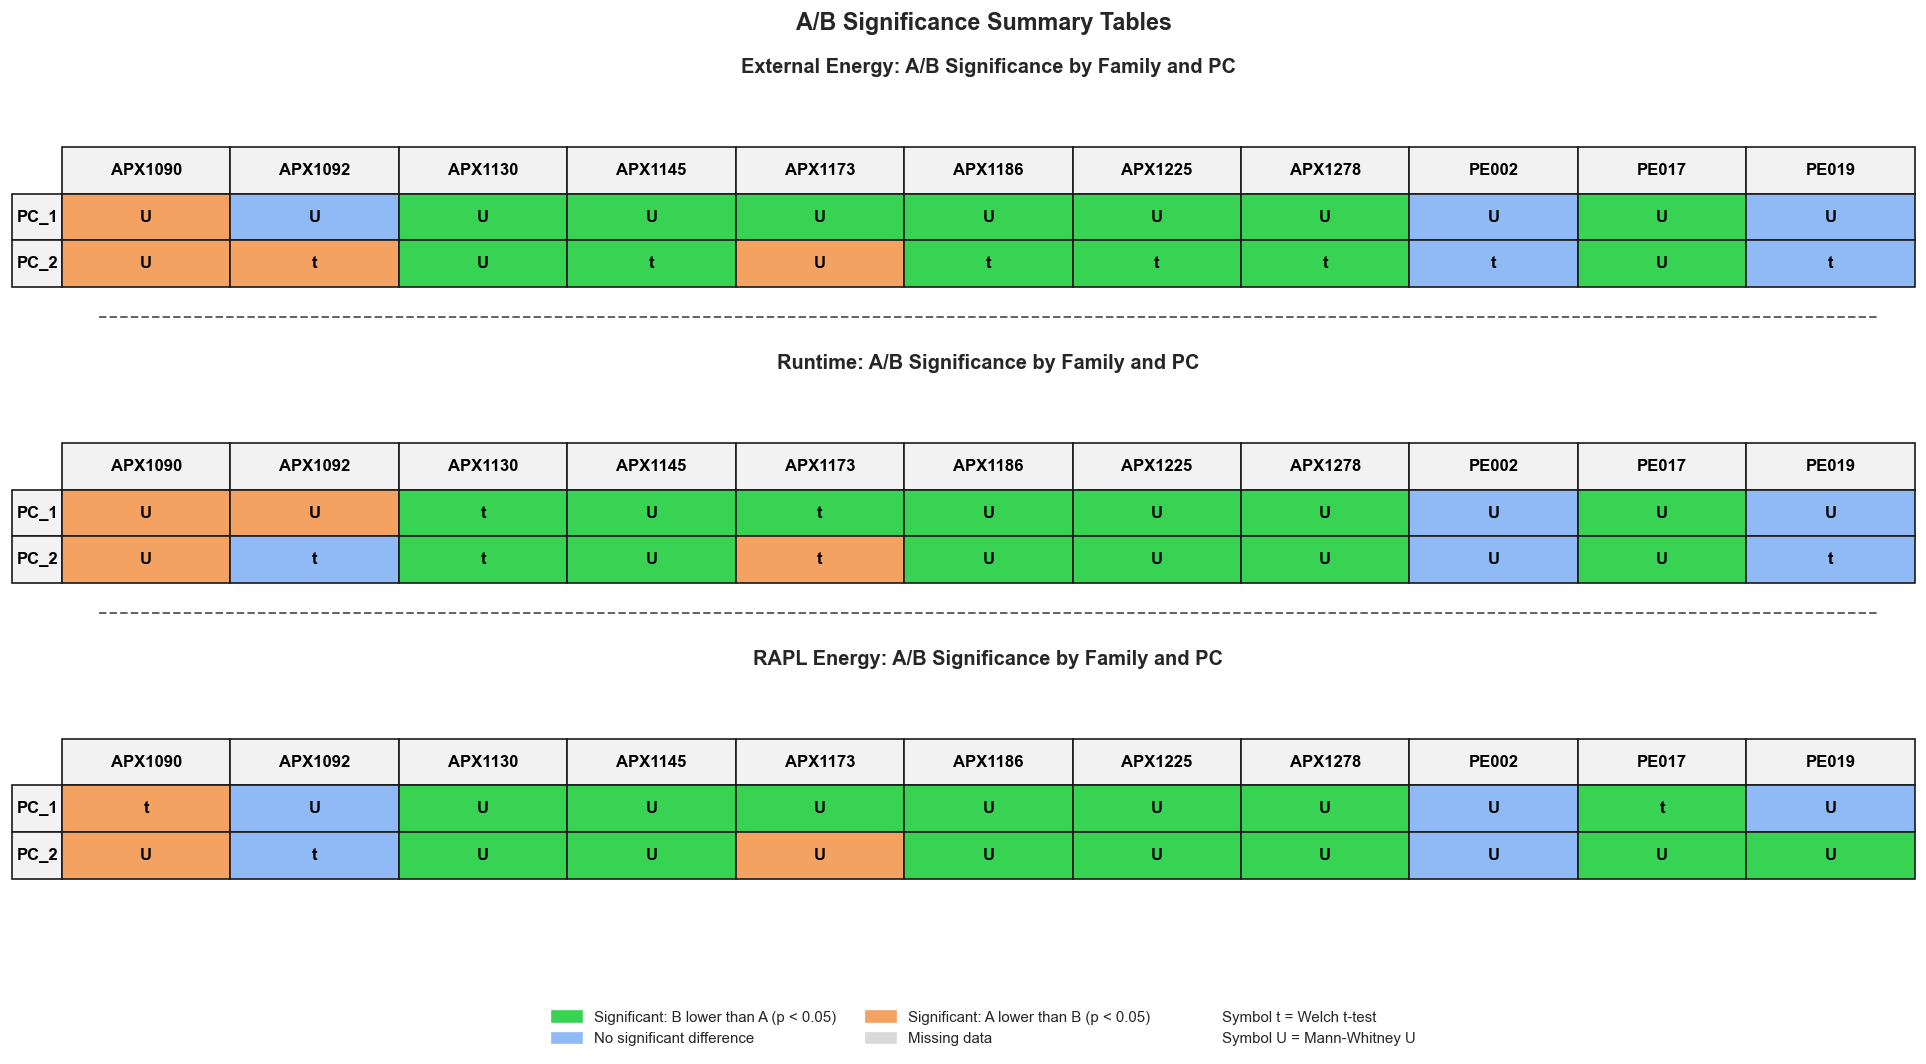

In [24]:
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D
from pathlib import Path

# Summary image tables: per-family A/B significance per PC.
# Color rules:
# - Green: significant (p < 0.05) and B lower than A (A_mean > B_mean)
# - Light blue: not significant
# - Orange: significant (p < 0.05) and A lower than B (A_mean < B_mean)
# Cell symbols indicate the test used.

if "stats_df" not in globals() or stats_df.empty:
    print("stats_df is not available. Run the A/B statistics cell first.")
else:
    save_dir = Path("plots")
    save_dir.mkdir(parents=True, exist_ok=True)

    color_green = "#39d353"
    color_blue = "#8fbaf5"
    color_orange = "#f4a261"
    color_missing = "#d9d9d9"

    symbol_map = {
        "welch_ttest": "t",
        "mannwhitney_u": "U",
    }

    metric_specs = [
        ("energy_external_j", "External Energy: A/B Significance by Family and PC"),
        ("runtime_sec", "Runtime: A/B Significance by Family and PC"),
        ("energy_rapl_j", "RAPL Energy: A/B Significance by Family and PC"),
    ]

    pcs_order = [pc for pc in ["PC_1", "PC_2"] if pc in set(stats_df["pc"])]

    def build_matrix_for_metric(metric_label: str):
        sdf = stats_df[stats_df["metric"] == metric_label].copy()
        if sdf.empty:
            return None, None, None

        families = sorted(sdf["query_family"].dropna().unique())

        text_matrix = []
        color_matrix = []

        for pc in pcs_order:
            row_text = []
            row_color = []

            for fam in families:
                row = sdf[(sdf["pc"] == pc) & (sdf["query_family"] == fam)]

                if row.empty:
                    row_text.append("-")
                    row_color.append(color_missing)
                    continue

                r = row.iloc[0]
                p = float(r["p_value"]) if pd.notna(r["p_value"]) else np.nan
                a_mean = float(r["A_mean"]) if pd.notna(r["A_mean"]) else np.nan
                b_mean = float(r["B_mean"]) if pd.notna(r["B_mean"]) else np.nan
                test_used = str(r["test_used"]) if pd.notna(r["test_used"]) else ""

                symbol = symbol_map.get(test_used, "?")
                row_text.append(symbol)

                if np.isnan(p) or np.isnan(a_mean) or np.isnan(b_mean):
                    row_color.append(color_missing)
                elif p < 0.05:
                    if b_mean < a_mean:
                        row_color.append(color_green)
                    elif a_mean < b_mean:
                        row_color.append(color_orange)
                    else:
                        row_color.append(color_blue)
                else:
                    row_color.append(color_blue)

            text_matrix.append(row_text)
            color_matrix.append(row_color)

        return families, text_matrix, color_matrix

    metric_payloads = []
    for metric_label, title in metric_specs:
        families, text_matrix, color_matrix = build_matrix_for_metric(metric_label)
        metric_payloads.append((metric_label, title, families, text_matrix, color_matrix))

    valid_payloads = [p for p in metric_payloads if p[2] is not None]
    if not valid_payloads:
        print("No rows found in stats_df for the requested significance metrics.")
    else:
        fig, axes = plt.subplots(
            len(metric_specs),
            1,
            figsize=(16, 9),
            gridspec_kw={"hspace": 0.18},
        )

        if len(metric_specs) == 1:
            axes = [axes]

        for idx, (ax, payload) in enumerate(zip(axes, metric_payloads)):
            metric_label, title, families, text_matrix, color_matrix = payload
            ax.axis("off")

            if families is None:
                ax.text(0.5, 0.5, f"No rows found for metric '{metric_label}'.", ha="center", va="center", transform=ax.transAxes)
            else:
                table = ax.table(
                    cellText=text_matrix,
                    cellLoc="center",
                    rowLabels=pcs_order,
                    colLabels=families,
                    bbox=[0.0, 0.16, 1.0, 0.56],
                )

                table.auto_set_font_size(False)
                table.set_fontsize(10)

                # Header style.
                for c in range(len(families)):
                    table[(0, c)].set_facecolor("#f2f2f2")
                    table[(0, c)].set_text_props(weight="bold", color="black")

                # Row label style.
                for r in range(1, len(pcs_order) + 1):
                    table[(r, -1)].set_facecolor("#f2f2f2")
                    table[(r, -1)].set_text_props(weight="bold", color="black")

                # Data cells.
                for r in range(len(pcs_order)):
                    for c in range(len(families)):
                        table[(r + 1, c)].set_facecolor(color_matrix[r][c])
                        table[(r + 1, c)].set_text_props(color="black", weight="bold")

            ax.set_title(title, fontsize=12, weight="bold", pad=2)

            # Visual divider between subtables.
            if idx < len(metric_specs) - 1:
                ax.plot([0.02, 0.98], [0.04, 0.04], transform=ax.transAxes, color="#666", linewidth=1.2, linestyle="--")

        legend_handles = [
            mpatches.Patch(color=color_green, label="Significant: B lower than A (p < 0.05)"),
            mpatches.Patch(color=color_blue, label="No significant difference"),
            mpatches.Patch(color=color_orange, label="Significant: A lower than B (p < 0.05)"),
            mpatches.Patch(color=color_missing, label="Missing data"),
            Line2D([0], [0], color="none", label="Symbol t = Welch t-test"),
            Line2D([0], [0], color="none", label="Symbol U = Mann-Whitney U"),
        ]

        fig.legend(
            handles=legend_handles,
            loc="lower center",
            bbox_to_anchor=(0.5, 0.01),
            frameon=False,
            ncol=3,
            fontsize=9,
        )

        fig.suptitle("A/B Significance Summary Tables", fontsize=14, weight="bold", y=0.98)
        fig.subplots_adjust(left=0.02, right=0.985, top=0.92, bottom=0.14, hspace=0.24)

        out_path = save_dir / "ab_significance_tables_combined.svg"
        fig.savefig(out_path, format="svg", bbox_inches="tight")
        print(f"Saved: {out_path}")
        plt.show()

Saved: plots\ab_mean_pct_diff_energy_external_j.svg


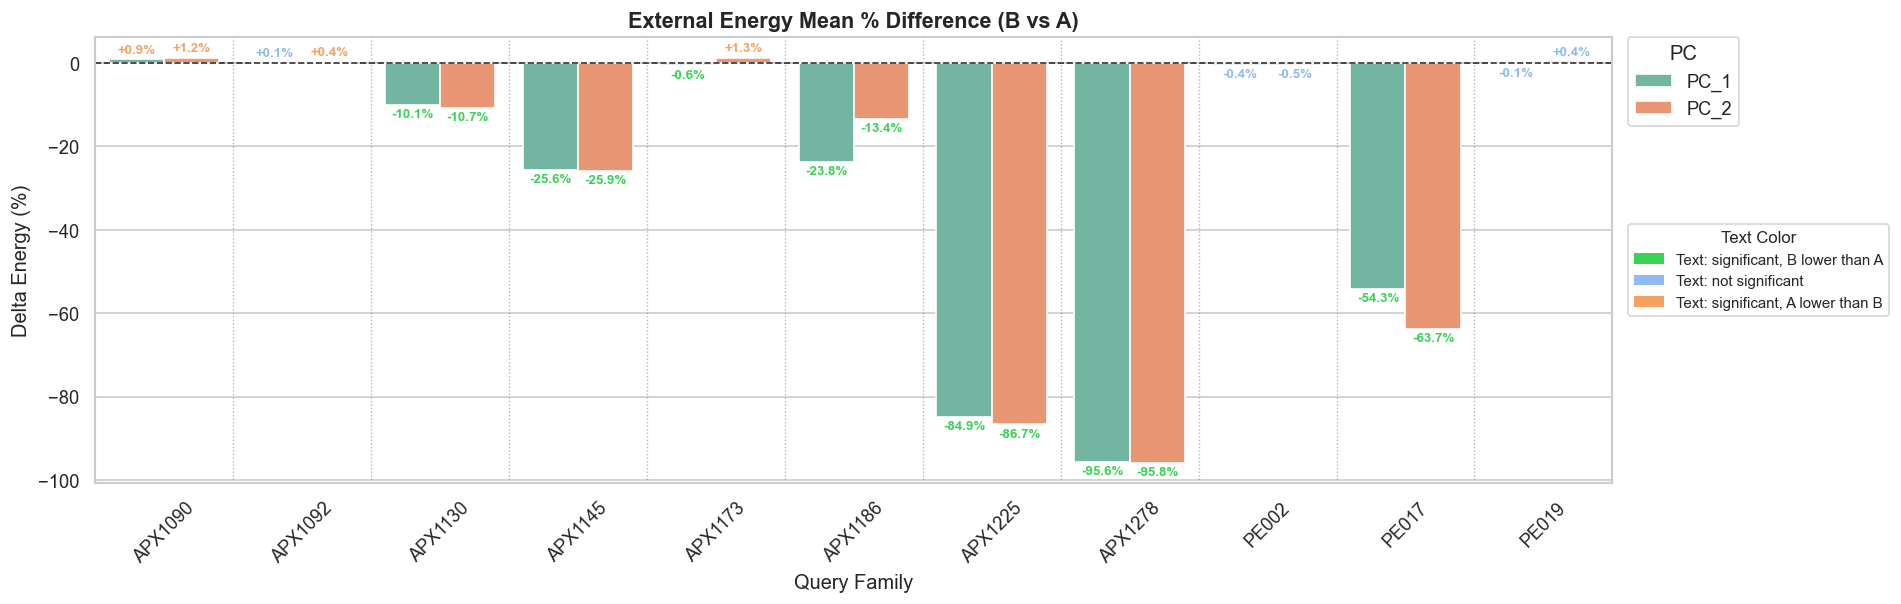

Saved: plots\ab_mean_pct_diff_runtime_sec.svg


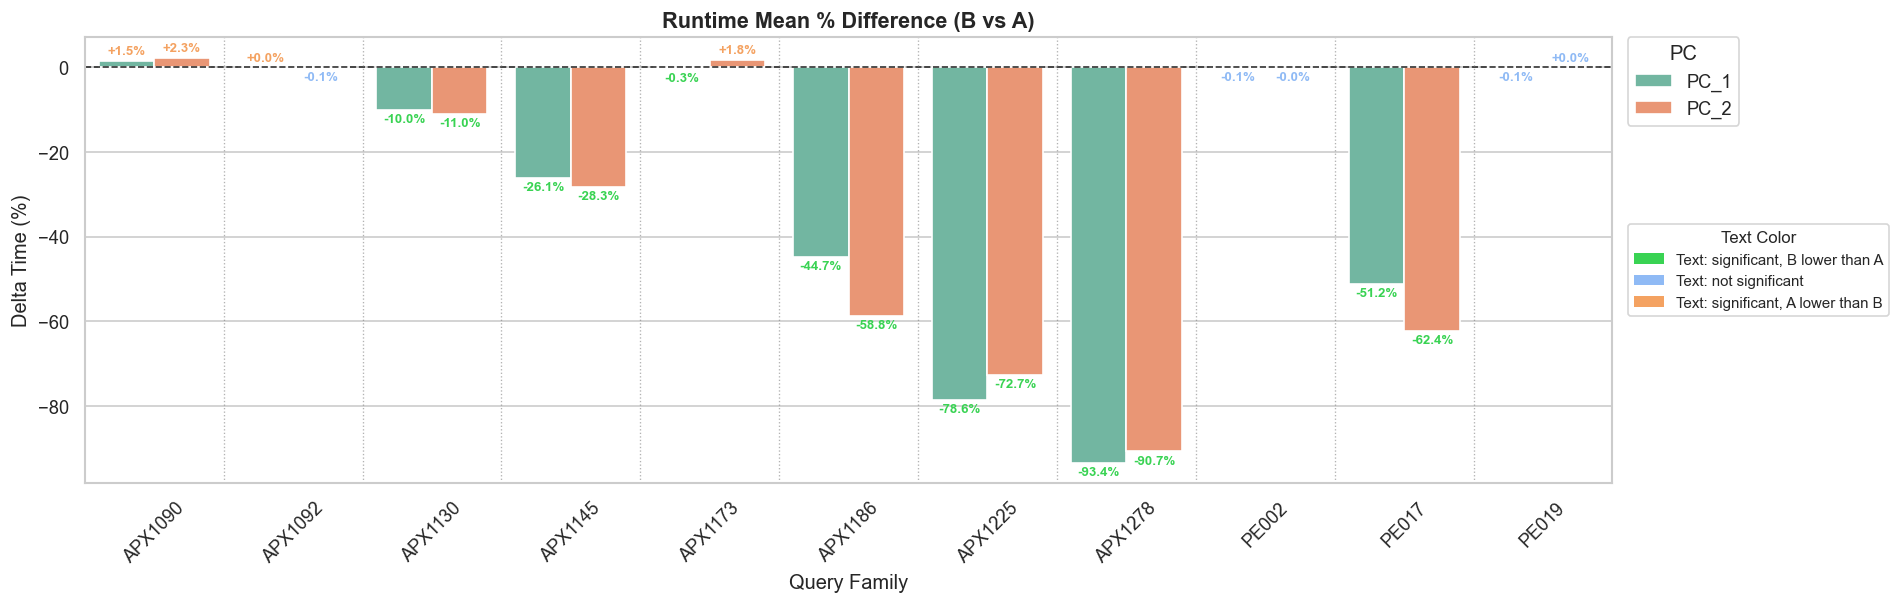

In [19]:
from pathlib import Path
import matplotlib.patches as mpatches

# A/B mean-difference plots by family with PC_1 and PC_2 side-by-side.
# Sign convention requested: negative when B is lower.
# We plot percent difference as 100 * (B_mean - A_mean) / A_mean.

if "stats_df" not in globals() or stats_df.empty:
    print("stats_df is not available. Run the A/B statistics cell first.")
else:
    save_dir = Path("plots")
    save_dir.mkdir(parents=True, exist_ok=True)

    # Same significance color scheme used in the statistics table cell.
    color_green = "#39d353"   # significant and B lower than A
    color_blue = "#8fbaf5"    # not significant
    color_orange = "#f4a261"  # significant and A lower than B

    diff_plot_metrics = [
        ("energy_external_j", "External Energy Mean % Difference (B vs A)", "Delta Energy (%)"),
        ("runtime_sec", "Runtime Mean % Difference (B vs A)", "Delta Time (%)"),
    ]

    pcs_order = [pc for pc in ["PC_1", "PC_2"] if pc in set(stats_df["pc"])]
    fam_order = sorted(stats_df["query_family"].dropna().unique())

    for metric_label, title, y_label in diff_plot_metrics:
        m = stats_df[stats_df["metric"] == metric_label].copy()

        fig, ax = plt.subplots(1, 1, figsize=(16, 5.2))

        if m.empty:
            ax.text(0.5, 0.5, f"No data for {metric_label}", ha="center", va="center", transform=ax.transAxes)
            ax.set_title(title)
            ax.set_ylabel(y_label)
            ax.set_xlabel("Query Family")
            ax.axhline(0, color="black", linewidth=1)
        else:
            m["B_minus_A_pct"] = np.where(
                m["A_mean"] != 0,
                100.0 * (m["B_mean"] - m["A_mean"]) / m["A_mean"],
                np.nan,
            )
            m = m.dropna(subset=["B_minus_A_pct"])

            # Text-label colors follow the significance theme from the summary table.
            m["label_color"] = np.where(
                (m["p_value"] < 0.05) & (m["B_mean"] < m["A_mean"]),
                color_green,
                np.where(
                    (m["p_value"] < 0.05) & (m["A_mean"] < m["B_mean"]),
                    color_orange,
                    color_blue,
                ),
            )

            label_color_map = {
                (row["pc"], row["query_family"]): row["label_color"]
                for _, row in m.iterrows()
            }

            sns.barplot(
                data=m,
                x="query_family",
                y="B_minus_A_pct",
                hue="pc",
                order=fam_order,
                hue_order=pcs_order,
                ax=ax,
                palette="Set2",
            )

            # Add signed percentage labels and color only the text by significance theme.
            for hue_idx, container in enumerate(ax.containers):
                pc_name = pcs_order[hue_idx] if hue_idx < len(pcs_order) else None
                for fam_idx, bar in enumerate(container):
                    h = bar.get_height()
                    if np.isnan(h):
                        continue

                    fam = fam_order[fam_idx] if fam_idx < len(fam_order) else None
                    txt_color = label_color_map.get((pc_name, fam), color_blue)

                    x = bar.get_x() + bar.get_width() / 2.0
                    y = h
                    va = "bottom" if h >= 0 else "top"
                    y_offset = 2 if h >= 0 else -2

                    ax.annotate(
                        f"{h:+.1f}%",
                        (x, y),
                        xytext=(0, y_offset),
                        textcoords="offset points",
                        ha="center",
                        va=va,
                        fontsize=8,
                        color=txt_color,
                        fontweight="bold",
                    )

            ax.axhline(0, color="black", linewidth=1, linestyle="--", alpha=0.8)
            ax.tick_params(axis="x", rotation=45)

            # Keep the same separator style used elsewhere in the notebook.
            for i in range(len(fam_order) - 1):
                ax.axvline(i + 0.5, linestyle=":", color="gray", linewidth=0.8, alpha=0.6)

            handles, labels = ax.get_legend_handles_labels()
            if handles:
                pc_legend = ax.legend(
                    handles,
                    labels,
                    title="PC",
                    loc="upper left",
                    bbox_to_anchor=(1.01, 1.0),
                    borderaxespad=0,
                )
                ax.add_artist(pc_legend)

                text_color_handles = [
                    mpatches.Patch(facecolor=color_green, edgecolor="none", label="Text: significant, B lower than A"),
                    mpatches.Patch(facecolor=color_blue, edgecolor="none", label="Text: not significant"),
                    mpatches.Patch(facecolor=color_orange, edgecolor="none", label="Text: significant, A lower than B"),
                ]
                ax.legend(
                    handles=text_color_handles,
                    title="Text Color",
                    loc="upper left",
                    bbox_to_anchor=(1.01, 0.58),
                    borderaxespad=0,
                    fontsize=9,
                    title_fontsize=10,
                )

        ax.set_title(title, fontsize=13, fontweight="bold")
        ax.set_ylabel(y_label)
        ax.set_xlabel("Query Family")
        plt.tight_layout()

        out_path = save_dir / f"ab_mean_pct_diff_{metric_label}.svg"
        fig.savefig(out_path, format="svg", bbox_inches="tight")
        print(f"Saved: {out_path}")
        plt.show()

Saved: plots\ab_savings_scatter_external_pct.svg

Per-query diagnostics:


,pc,query_family,time_saving_pct,energy_saving_pct,saving_gap,energy_over_time
0,PC_1,APX1090,-1.524,-0.924,0.600,0.606
1,PC_1,APX1092,-0.032,-0.113,-0.081,3.521
2,PC_1,APX1130,10.049,10.096,0.046,1.005
3,PC_1,APX1145,26.064,25.647,-0.417,0.984
4,PC_1,APX1173,0.276,0.587,0.311,2.126
5,PC_1,APX1186,44.733,23.761,-20.972,0.531
6,PC_1,APX1225,78.568,84.925,6.357,1.081
7,PC_1,APX1278,93.407,95.599,2.192,1.023
8,PC_1,PE002,0.076,0.444,0.368,5.841
9,PC_1,PE017,51.217,54.266,3.048,1.060


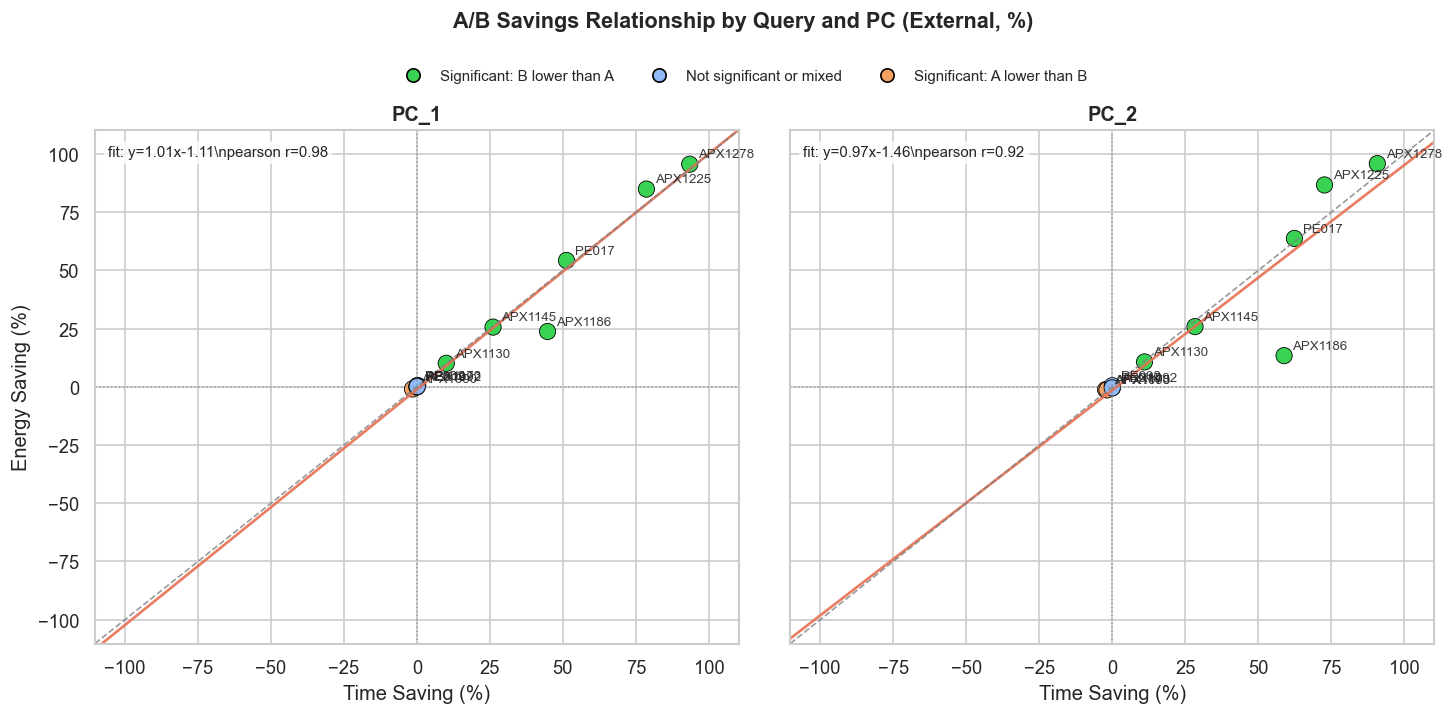

Saved: plots\ab_savings_scatter_external_abs.svg

Per-query diagnostics:


,pc,query_family,time_saving_abs,energy_saving_abs,saving_gap,energy_over_time
0,PC_1,APX1090,-1.749,-13.467,-11.718,7.698
1,PC_1,APX1092,-0.048,-3.130,-3.082,65.114
2,PC_1,APX1130,19.474,246.216,226.741,12.643
3,PC_1,APX1145,28.422,484.764,456.342,17.056
4,PC_1,APX1173,0.553,14.645,14.092,26.462
5,PC_1,APX1186,60.283,394.804,334.522,6.549
6,PC_1,APX1225,38.602,711.714,673.112,18.437
7,PC_1,APX1278,80.675,1427.902,1347.227,17.700
8,PC_1,PE002,0.007,0.495,0.488,69.278
9,PC_1,PE017,176.551,2416.398,2239.847,13.687


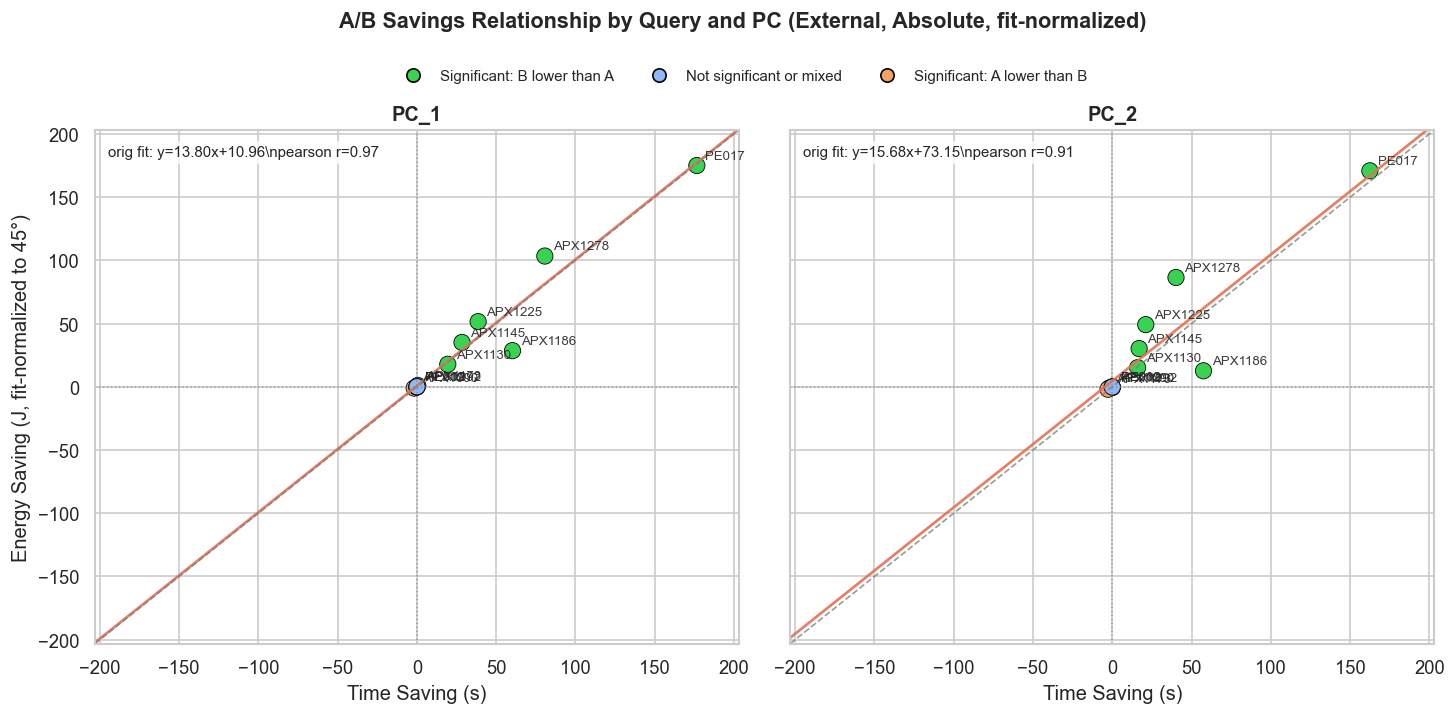

Saved: plots\ab_savings_scatter_rapl_pct.svg

Per-query diagnostics:


,pc,query_family,time_saving_pct,energy_saving_pct,saving_gap,energy_over_time
0,PC_1,APX1090,-1.524,-1.300,0.224,0.853
1,PC_1,APX1092,-0.032,-0.200,-0.168,6.254
2,PC_1,APX1130,10.049,10.116,0.067,1.007
3,PC_1,APX1145,26.064,25.852,-0.212,0.992
4,PC_1,APX1173,0.276,0.803,0.527,2.907
5,PC_1,APX1186,44.733,13.520,-31.212,0.302
6,PC_1,APX1225,78.568,86.417,7.849,1.100
7,PC_1,APX1278,93.407,96.012,2.605,1.028
8,PC_1,PE002,0.076,0.063,-0.013,0.834
9,PC_1,PE017,51.217,55.811,4.594,1.090


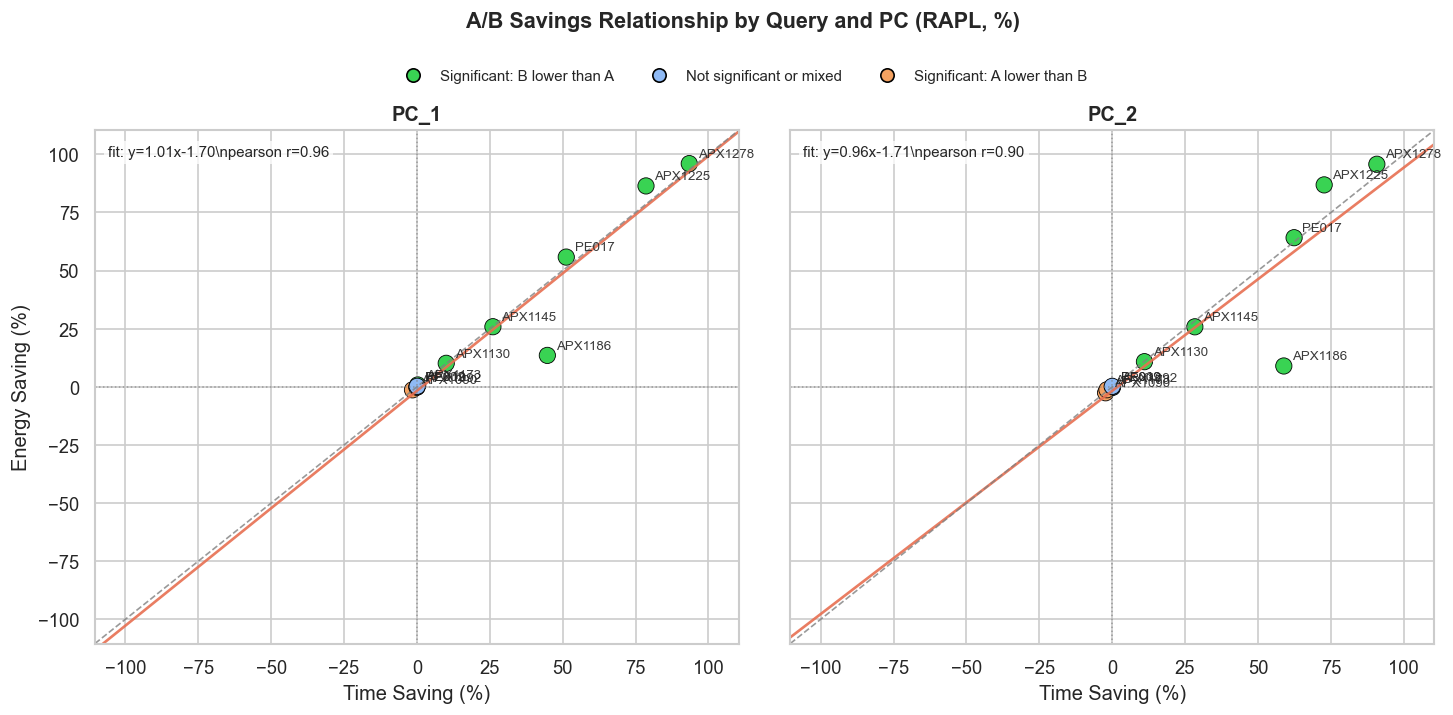

Saved: plots\ab_savings_scatter_rapl_abs.svg

Per-query diagnostics:


,pc,query_family,time_saving_abs,energy_saving_abs,saving_gap,energy_over_time
0,PC_1,APX1090,-1.749,-10.903,-9.153,6.232
1,PC_1,APX1092,-0.048,-3.533,-3.485,73.500
2,PC_1,APX1130,19.474,142.698,123.223,7.327
3,PC_1,APX1145,28.422,320.533,292.112,11.278
4,PC_1,APX1173,0.553,11.586,11.033,20.935
5,PC_1,APX1186,60.283,128.474,68.191,2.131
6,PC_1,APX1225,38.602,466.840,428.237,12.094
7,PC_1,APX1278,80.675,936.963,856.289,11.614
8,PC_1,PE002,0.007,0.041,0.034,5.708
9,PC_1,PE017,176.551,1462.780,1286.229,8.285


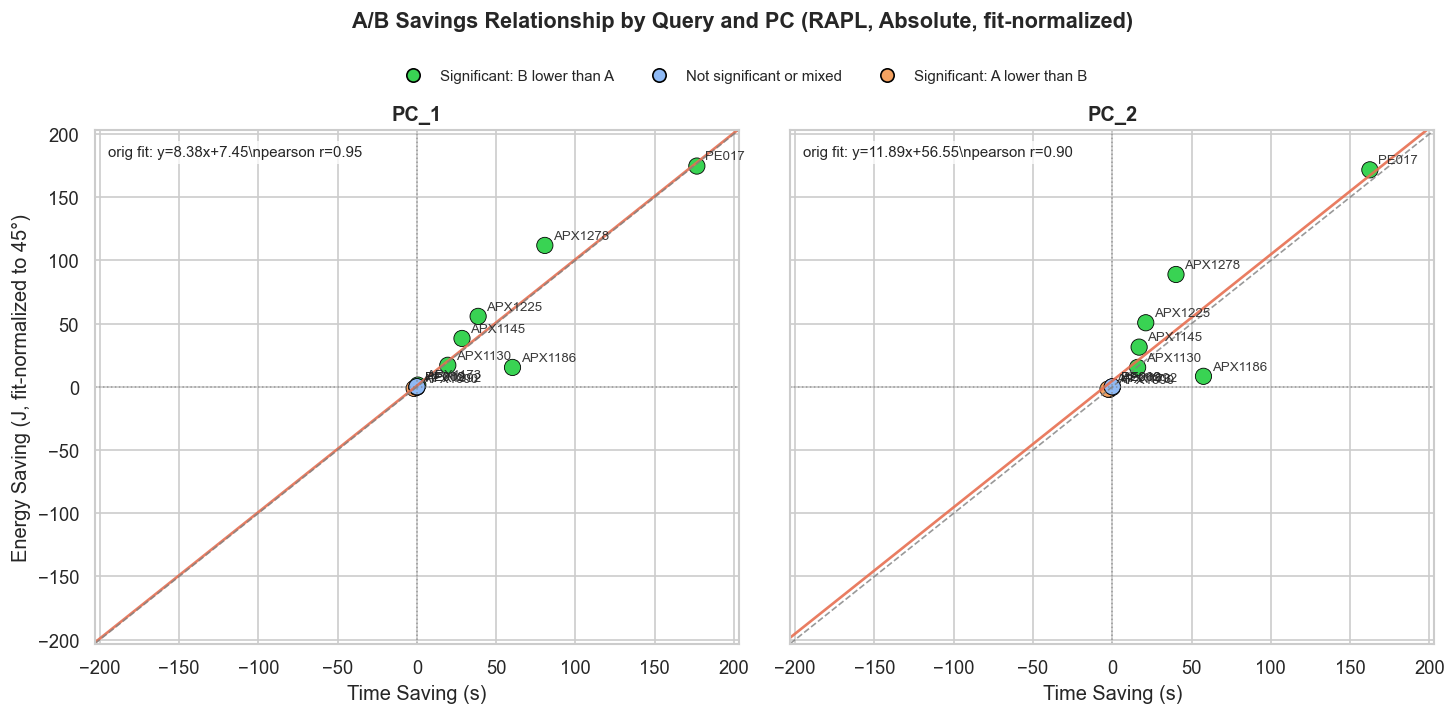

In [22]:
from pathlib import Path
from matplotlib.lines import Line2D

# Scatter views of direct A/B savings relationship.
# Percent saving: 100 * (A_mean - B_mean) / A_mean
# Absolute saving: A_mean - B_mean
if "stats_df" not in globals() or stats_df.empty:
    print("stats_df is not available. Run the A/B statistics cell first.")
else:
    color_green = "#39d353"   # significant and B lower than A
    color_blue = "#8fbaf5"    # not significant / mixed
    color_orange = "#f4a261"  # significant and A lower than B

    def build_scatter_base(metric_energy: str) -> pd.DataFrame:
        needed_metrics = ["runtime_sec", metric_energy]
        base = stats_df[stats_df["metric"].isin(needed_metrics)].copy()

        if base.empty:
            return pd.DataFrame()

        base["saving_pct"] = np.where(
            base["A_mean"] != 0,
            100.0 * (base["A_mean"] - base["B_mean"]) / base["A_mean"],
            np.nan,
        )
        base["saving_abs"] = base["A_mean"] - base["B_mean"]
        base["is_sig"] = base["p_value"] < 0.05
        base["b_lower"] = base["B_mean"] < base["A_mean"]

        pct_df = (
            base.pivot_table(
                index=["pc", "query_family"],
                columns="metric",
                values="saving_pct",
                aggfunc="mean",
            )
            .reset_index()
            .rename_axis(None, axis=1)
        )

        abs_df = (
            base.pivot_table(
                index=["pc", "query_family"],
                columns="metric",
                values="saving_abs",
                aggfunc="mean",
            )
            .reset_index()
            .rename_axis(None, axis=1)
        )

        meta = base.pivot_table(
            index=["pc", "query_family"],
            columns="metric",
            values=["is_sig", "b_lower"],
            aggfunc="first",
        ).reset_index()

        meta.columns = [
            f"{col[0]}_{col[1]}" if isinstance(col, tuple) and col[0] not in ["pc", "query_family"] else (col[0] if isinstance(col, tuple) else col)
            for col in meta.columns
        ]

        rename_map = {
            "is_sig_runtime_sec": "sig_time",
            f"is_sig_{metric_energy}": "sig_energy",
            "b_lower_runtime_sec": "b_lower_time",
            f"b_lower_{metric_energy}": "b_lower_energy",
        }
        meta = meta.rename(columns=rename_map)

        for c in ["sig_time", "sig_energy", "b_lower_time", "b_lower_energy"]:
            if c not in meta.columns:
                meta[c] = False

        out = pct_df.merge(
            abs_df,
            on=["pc", "query_family"],
            how="inner",
            suffixes=("_pct", "_abs"),
        )

        expected_cols = {
            "runtime_sec_pct": "time_saving_pct",
            f"{metric_energy}_pct": "energy_saving_pct",
            "runtime_sec_abs": "time_saving_abs",
            f"{metric_energy}_abs": "energy_saving_abs",
        }

        out = out.rename(columns=expected_cols)
        out = out.dropna(subset=["time_saving_pct", "energy_saving_pct", "time_saving_abs", "energy_saving_abs"])

        out = out.merge(
            meta[["pc", "query_family", "sig_time", "sig_energy", "b_lower_time", "b_lower_energy"]],
            on=["pc", "query_family"],
            how="left",
        )

        out["theme_class"] = np.select(
            [
                (out["sig_time"] & out["b_lower_time"] & out["sig_energy"] & out["b_lower_energy"]),
                ((out["sig_time"] & (~out["b_lower_time"])) | (out["sig_energy"] & (~out["b_lower_energy"]))),
            ],
            ["sig_B_lower", "sig_A_lower"],
            default="nonsig_or_mixed",
        )

        return out

    def plot_scatter(
        df: pd.DataFrame,
        x_col: str,
        y_col: str,
        x_label: str,
        y_label: str,
        title: str,
        out_name: str,
        normalize_to_fit_45: bool = False,
    ):
        if df.empty:
            print(f"No complete data for {title}.")
            return

        theme_palette = {
            "sig_B_lower": color_green,
            "nonsig_or_mixed": color_blue,
            "sig_A_lower": color_orange,
        }

        eps = 1e-9
        df = df.copy()

        pcs_order = [pc for pc in ["PC_1", "PC_2"] if pc in set(df["pc"])]
        if not pcs_order:
            pcs_order = sorted(df["pc"].dropna().unique())

        ncols = max(len(pcs_order), 1)
        fig, axes = plt.subplots(
            1,
            ncols,
            figsize=(7.2 * ncols, 6.2),
            sharex=True,
            sharey=True,
            constrained_layout=False,
        )
        if ncols == 1:
            axes = [axes]

        # Build per-PC transformed y-values (for absolute plots) so the fitted trend is at 45°.
        transformed_subsets = []
        for pc_name in pcs_order:
            subset = df[df["pc"] == pc_name].copy()
            x = subset[x_col].to_numpy()
            y = subset[y_col].to_numpy()

            if normalize_to_fit_45 and len(subset) >= 2:
                m, b = np.polyfit(x, y, 1)
                if np.isfinite(m) and np.abs(m) > eps:
                    subset["_y_plot"] = subset[y_col] / m
                    subset["_fit_slope_orig"] = m
                    subset["_fit_intercept_orig"] = b
                else:
                    subset["_y_plot"] = subset[y_col]
                    subset["_fit_slope_orig"] = np.nan
                    subset["_fit_intercept_orig"] = np.nan
            else:
                subset["_y_plot"] = subset[y_col]
                subset["_fit_slope_orig"] = np.nan
                subset["_fit_intercept_orig"] = np.nan

            transformed_subsets.append(subset)

        plot_df = pd.concat(transformed_subsets, ignore_index=True)

        lim_max = np.nanmax(np.abs(np.r_[plot_df[x_col].to_numpy(), plot_df["_y_plot"].to_numpy()]))
        lim = max(5.0, float(lim_max) * 1.15)

        for i, pc_name in enumerate(pcs_order):
            ax = axes[i]
            subset = plot_df[plot_df["pc"] == pc_name].copy()

            sns.scatterplot(
                data=subset,
                x=x_col,
                y="_y_plot",
                hue="theme_class",
                hue_order=["sig_B_lower", "nonsig_or_mixed", "sig_A_lower"],
                palette=theme_palette,
                s=95,
                edgecolor="black",
                linewidth=0.5,
                legend=False,
                ax=ax,
            )

            for _, row in subset.iterrows():
                ax.annotate(
                    row["query_family"],
                    (row[x_col], row["_y_plot"]),
                    xytext=(5, 4),
                    textcoords="offset points",
                    fontsize=8,
                    alpha=0.9,
                )

            x = subset[x_col].to_numpy()
            y_plot = subset["_y_plot"].to_numpy()
            y_orig = subset[y_col].to_numpy()

            if len(subset) >= 2:
                rho = np.corrcoef(x, y_orig)[0, 1]

                if normalize_to_fit_45:
                    # In transformed space, the trend is y ~= x + c.
                    fit_intercept = float(np.nanmean(y_plot - x)) if len(subset) > 0 else 0.0
                    xx = np.array([-lim, lim])
                    yy = xx + fit_intercept
                    ax.plot(xx, yy, color="#e76f51", linewidth=1.6, linestyle="-", alpha=0.9)

                    m_orig = subset["_fit_slope_orig"].dropna()
                    b_orig = subset["_fit_intercept_orig"].dropna()
                    m_txt = float(m_orig.iloc[0]) if len(m_orig) else np.nan
                    b_txt = float(b_orig.iloc[0]) if len(b_orig) else np.nan

                    ax.text(
                        0.02,
                        0.97,
                        f"orig fit: y={m_txt:.2f}x{b_txt:+.2f}\\npearson r={rho:.2f}",
                        transform=ax.transAxes,
                        va="top",
                        ha="left",
                        fontsize=9,
                        bbox=dict(facecolor="white", alpha=0.75, edgecolor="none", pad=2.5),
                    )
                else:
                    m, b = np.polyfit(x, y_plot, 1)
                    xx = np.array([-lim, lim])
                    yy = m * xx + b
                    ax.plot(xx, yy, color="#e76f51", linewidth=1.6, linestyle="-", alpha=0.9)
                    ax.text(
                        0.02,
                        0.97,
                        f"fit: y={m:.2f}x{b:+.2f}\\npearson r={rho:.2f}",
                        transform=ax.transAxes,
                        va="top",
                        ha="left",
                        fontsize=9,
                        bbox=dict(facecolor="white", alpha=0.75, edgecolor="none", pad=2.5),
                    )

            # 45° reference in plot space.
            ax.plot([-lim, lim], [-lim, lim], linestyle="--", color="gray", linewidth=1.0, alpha=0.8)
            ax.axhline(0.0, linestyle=":", color="gray", linewidth=0.9, alpha=0.7)
            ax.axvline(0.0, linestyle=":", color="gray", linewidth=0.9, alpha=0.7)
            ax.set_xlim(-lim, lim)
            ax.set_ylim(-lim, lim)
            ax.set_title(f"{pc_name}", fontsize=12, fontweight="bold")
            ax.set_xlabel(x_label)
            if i == 0:
                ax.set_ylabel(y_label)
            else:
                ax.set_ylabel("")

        legend_handles = [
            Line2D([0], [0], marker="o", color="w", markerfacecolor=color_green, markeredgecolor="black", markersize=8, label="Significant: B lower than A"),
            Line2D([0], [0], marker="o", color="w", markerfacecolor=color_blue, markeredgecolor="black", markersize=8, label="Not significant or mixed"),
            Line2D([0], [0], marker="o", color="w", markerfacecolor=color_orange, markeredgecolor="black", markersize=8, label="Significant: A lower than B"),
        ]
        fig.legend(handles=legend_handles, loc="upper center", bbox_to_anchor=(0.5, 0.90), ncol=3, frameon=False, fontsize=9)

        fig.subplots_adjust(top=0.80, wspace=0.08)
        fig.suptitle(title, fontsize=13, fontweight="bold", y=0.96)

        save_dir = Path("plots")
        save_dir.mkdir(parents=True, exist_ok=True)
        out_path = save_dir / out_name
        fig.savefig(out_path, format="svg", bbox_inches="tight")
        print(f"Saved: {out_path}")

        if normalize_to_fit_45:
            df["energy_over_time"] = np.where(
                np.abs(df[x_col]) > eps,
                df[y_col] / df[x_col],
                np.nan,
            )
            df["saving_gap"] = df[y_col] - df[x_col]
            display_cols = ["pc", "query_family", x_col, y_col, "saving_gap", "energy_over_time"]
        else:
            df["energy_over_time"] = np.where(
                np.abs(df[x_col]) > eps,
                df[y_col] / df[x_col],
                np.nan,
            )
            df["saving_gap"] = df[y_col] - df[x_col]
            display_cols = ["pc", "query_family", x_col, y_col, "saving_gap", "energy_over_time"]

        print("\nPer-query diagnostics:")
        display(df[display_cols].sort_values(["pc", "query_family"]).reset_index(drop=True).round(3))
        plt.show()

    # Build and plot external-energy and RAPL-energy variants, each in % and absolute units.
    external_df = build_scatter_base("energy_external_j")
    rapl_df = build_scatter_base("energy_rapl_j")

    plot_scatter(
        external_df,
        x_col="time_saving_pct",
        y_col="energy_saving_pct",
        x_label="Time Saving (%)",
        y_label="Energy Saving (%)",
        title="A/B Savings Relationship by Query and PC (External, %)",
        out_name="ab_savings_scatter_external_pct.svg",
    )

    plot_scatter(
        external_df,
        x_col="time_saving_abs",
        y_col="energy_saving_abs",
        x_label="Time Saving (s)",
        y_label="Energy Saving (J, fit-normalized to 45°)",
        title="A/B Savings Relationship by Query and PC (External, Absolute, fit-normalized)",
        out_name="ab_savings_scatter_external_abs.svg",
        normalize_to_fit_45=True,
    )

    plot_scatter(
        rapl_df,
        x_col="time_saving_pct",
        y_col="energy_saving_pct",
        x_label="Time Saving (%)",
        y_label="Energy Saving (%)",
        title="A/B Savings Relationship by Query and PC (RAPL, %)",
        out_name="ab_savings_scatter_rapl_pct.svg",
    )

    plot_scatter(
        rapl_df,
        x_col="time_saving_abs",
        y_col="energy_saving_abs",
        x_label="Time Saving (s)",
        y_label="Energy Saving (J, fit-normalized to 45°)",
        title="A/B Savings Relationship by Query and PC (RAPL, Absolute, fit-normalized)",
        out_name="ab_savings_scatter_rapl_abs.svg",
        normalize_to_fit_45=True,
    )

In [ ]:
# Save core presentation figures to plots/ (reproducible exports)
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

save_dir = Path("plots")
save_dir.mkdir(parents=True, exist_ok=True)

def _save_avg_power_plot():
    if "avg_long" not in globals() or avg_long is None or avg_long.empty:
        print("Skip avg power export: avg_long not available.")
        return
    g = sns.catplot(
        data=avg_long,
        x="query_family",
        y="avg_power_w",
        hue="variant",
        row="pc",
        col="source",
        row_order=["PC_1", "PC_2"],
        col_order=["RAPL", "External"],
        order=query_order,
        kind="box",
        height=3.7,
        aspect=1.7,
        sharey="row",
    )
    g.set_axis_labels("Query Family", "Average Power (W)")
    g.set_titles(row_template="{row_name}", col_template="{col_name}")
    for ax in g.axes.flat:
        ax.tick_params(axis="x", rotation=45)
    add_query_dividers(g, len(query_order))
    plt.tight_layout()
    out_path = save_dir / "ab_avg_power_boxplot.svg"
    g.figure.savefig(out_path, format="svg", bbox_inches="tight")
    print(f"Saved: {out_path}")
    plt.close(g.figure)

def _save_energy_plot():
    if "energy_long" not in globals() or energy_long is None or energy_long.empty:
        print("Skip energy export: energy_long not available.")
        return
    g = sns.catplot(
        data=energy_long,
        x="query_family",
        y="energy_j",
        hue="variant",
        row="pc",
        col="source",
        row_order=["PC_1", "PC_2"],
        col_order=["RAPL", "External"],
        order=query_order,
        kind="box",
        height=3.7,
        aspect=1.7,
        sharey="row",
    )
    g.set_axis_labels("Query Family", "Total Energy (J)")
    g.set_titles(row_template="{row_name}", col_template="{col_name}")
    for ax in g.axes.flat:
        ax.tick_params(axis="x", rotation=45)
    add_query_dividers(g, len(query_order))
    plt.tight_layout()
    out_path = save_dir / "ab_total_energy_boxplot.svg"
    g.figure.savefig(out_path, format="svg", bbox_inches="tight")
    print(f"Saved: {out_path}")
    plt.close(g.figure)

def _save_runtime_plot():
    if "runtime_df" not in globals() or runtime_df is None or runtime_df.empty:
        print("Skip runtime export: runtime_df not available.")
        return
    g = sns.catplot(
        data=runtime_df,
        x="query_family",
        y="total_elapsed_sec",
        hue="variant",
        row="pc",
        row_order=["PC_1", "PC_2"],
        order=query_order,
        kind="box",
        height=4.2,
        aspect=3.6,
        sharey=False,
    )
    g.set_axis_labels("Query Family", "Run Time (s)")
    g.set_titles(row_template="{row_name}")
    for ax in g.axes.flat:
        ax.tick_params(axis="x", rotation=45)
    add_query_dividers(g, len(query_order))
    plt.tight_layout()
    out_path = save_dir / "ab_runtime_boxplot.svg"
    g.figure.savefig(out_path, format="svg", bbox_inches="tight")
    print(f"Saved: {out_path}")
    plt.close(g.figure)

def _save_sig_counts_plot():
    local_sig_counts = None
    if "sig_counts" in globals() and isinstance(sig_counts, pd.DataFrame) and not sig_counts.empty:
        local_sig_counts = sig_counts.copy()
    elif "stats_df" in globals() and isinstance(stats_df, pd.DataFrame) and not stats_df.empty:
        local_sig_counts = (
            stats_df.groupby(["pc", "metric"], as_index=False)["significant_0_05"]
            .sum()
            .rename(columns={"significant_0_05": "n_significant_families"})
        )
    if local_sig_counts is None or local_sig_counts.empty:
        print("Skip significance-count export: no stats available.")
        return

    plt.figure(figsize=(12, 5))
    sns.barplot(
        data=local_sig_counts,
        x="metric",
        y="n_significant_families",
        hue="pc",
        palette="Set2",
    )
    plt.xticks(rotation=35, ha="right")
    plt.xlabel("Metric")
    plt.ylabel("Significant Families (p < 0.05)")
    plt.title("Significant A/B Families by PC and Metric")
    plt.tight_layout()
    out_path = save_dir / "ab_significant_counts_by_pc_metric.svg"
    plt.savefig(out_path, format="svg", bbox_inches="tight")
    print(f"Saved: {out_path}")
    plt.close()

_save_avg_power_plot()
_save_energy_plot()
_save_runtime_plot()
_save_sig_counts_plot()